# Drift–skill relationship figures

This notebook focuses on the drift–skill relationship formerly shown in Section 6 of the combined analysis notebook. It reads only the multi-region source products written by `0_run_drift_diag.ipynb`. Separate figures are produced for Niño3.4 and the North Atlantic, with global land retained for H2OSOI.

Each point is one initialization year. The within-strategy figures relate mean early change in absolute observation distance to later RMS observation error. The paired figures instead relate the FOSIRL-minus-Reanalysis early-drift difference to the corresponding later-error difference for the same year. Negative early drift means movement closer to observations; negative paired values favor FOSIRL.
Input preparation is automatic with `DRIFT_INPUT_MODE="auto"`; the `0_run_drift_input` and `0_run_drift_diag` notebooks are optional batch drivers. Raw hindcast, observation, and historical reference archives must be available when inputs need building.


In [27]:
import os
import sys
from pathlib import Path

_repo_override = os.environ.get("ESP_LAB_REPO_ROOT")
_repo_candidates = ([Path(_repo_override).expanduser().resolve()] if _repo_override
                    else [Path.cwd().resolve(), *Path.cwd().resolve().parents])
REPO_ROOT = next((p for p in _repo_candidates
                 if (p / "workflows" / "diagnostics" / "drift_inputs.py").is_file()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Start Jupyter inside ESP-Lab or set ESP_LAB_REPO_ROOT to its checkout.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from workflows.diagnostics.drift_inputs import ensure_reference, ensure_regional_products

%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd
import xarray as xr

from esp_lab.diagnostics.two_reference_drift import (
    bootstrap_paired_correlation_ci,
    compare_drift_skill_relationship,
    compute_early_drift_late_error,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Supporting configuration

In [28]:
OUTPUT_ROOT = Path(
    '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/'
    'two_reference'
)
FIGURE_ROOT = Path('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag')
VARIABLES = ('TREFHT', 'SST', 'PSL', 'PRECT', 'H2OSOI')
INIT_MONTHS = (5, 11)
SOURCES = ('JRA55_FOSIRL', 'Reanalysis')
SOURCE_LABELS = {'JRA55_FOSIRL': 'FOSIRL', 'Reanalysis': 'Reanalysis'}
SOURCE_COLORS = {'JRA55_FOSIRL': 'tab:blue', 'Reanalysis': 'tab:orange'}
SOURCE_MARKERS = {'JRA55_FOSIRL': 'o', 'Reanalysis': 's'}
MONTH_NAMES = {5: 'May', 11: 'November'}
PLOT_REGIONS = {
    'TREFHT': ('Nino3.4', 'North_Atlantic'),
    'SST': ('Nino3.4', 'North_Atlantic'),
    'PSL': ('Nino3.4', 'North_Atlantic'),
    'PRECT': ('Nino3.4', 'North_Atlantic'),
    'H2OSOI': ('Global_land',),
}
REGION_LABELS = {
    'Nino3.4': 'Niño3.4 (5°S–5°N, 190°–240°E)',
    'North_Atlantic': 'North Atlantic (0°–60°N, 80°W–0°)',
    'Global_land': 'Global land',
}
REGION_FILE_LABELS = {
    'Nino3.4': 'Nino3_4',
    'North_Atlantic': 'North_Atlantic',
    'Global_land': 'Global_land',
}
EARLY_LEADS = (1, 2, 3)
LATE_ERROR_WINDOWS = tuple(
    tuple(range(start, start + 3)) for start in range(7, 25, 3)
)
N_BOOTSTRAP = 2000
BOOTSTRAP_CONFIDENCE = 0.95
BOOTSTRAP_SEED = 42

# Figure layout and output
FIGURE_DPI = 180
FIGURE_SCALE = 1.0
PANEL_WIDTH = 5.5
PANEL_ASPECT_RATIO = (4, 3)
SHOW_FIGURES_INLINE = True
FIGURE_PREFIX = 'fig_leadtime_drift_two_reference'

# Typography: all sizes scale from the base font size
FONT_SIZE = 14
TITLE_FONT_SIZE = round(1.25 * FONT_SIZE)
LEGEND_FONT_SIZE = round(0.85 * FONT_SIZE)
ANNOTATION_FONT_SIZE = round(0.85 * FONT_SIZE)
TICK_FONT_SIZE = round(0.85 * FONT_SIZE)

# Scatter styling
SCATTER_SIZE = 60
PAIRED_SCATTER_SIZE = 80
SCATTER_ALPHA = 0.75

FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    'font.size': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'figure.titlesize': TITLE_FONT_SIZE,
    'legend.fontsize': LEGEND_FONT_SIZE,
    'xtick.labelsize': TICK_FONT_SIZE,
    'ytick.labelsize': TICK_FONT_SIZE,
})


def figure_size():
    panel_height = PANEL_WIDTH * PANEL_ASPECT_RATIO[1] / PANEL_ASPECT_RATIO[0]
    return (
        FIGURE_SCALE * len(INIT_MONTHS) * PANEL_WIDTH,
        FIGURE_SCALE * len(LATE_ERROR_WINDOWS) * panel_height,
    )


def lead_window_label(leads):
    return f'L{int(leads[0])}–L{int(leads[-1])}'
# auto: reuse compatible products and build missing/stale inputs;
# require: validate only; rebuild: regenerate derived inputs.
DRIFT_INPUT_MODE = "auto"


### Load the required regional fields

Only `delta_abs_e_obs` and `e_obs` are needed. Spatial maps, skill metrics, regime fractions, and paired products are not opened.

In [29]:
regional_manifest = ensure_regional_products(
    OUTPUT_ROOT, VARIABLES, INIT_MONTHS, SOURCES, PLOT_REGIONS,
    mode=DRIFT_INPUT_MODE,
)
expected_products = len(VARIABLES) * len(INIT_MONTHS) * len(SOURCES)
if len(regional_manifest) != expected_products:
    raise ValueError(
        f'Expected {expected_products} regional products, found '
        f'{len(regional_manifest)}'
    )
if regional_manifest.duplicated(['variable', 'init_month', 'source']).any():
    raise ValueError('Regional manifest contains duplicate products')


def regional_product_path(variable, init_month, source):
    match = regional_manifest.loc[
        regional_manifest['variable'].eq(variable)
        & regional_manifest['init_month'].eq(init_month)
        & regional_manifest['source'].eq(source),
        'path',
    ]
    if len(match) != 1:
        raise ValueError(
            f'Expected one product for {variable}, init={init_month:02d}, '
            f'{source}; found {len(match)}'
        )
    return Path(match.iloc[0])


def load_drift_skill_inputs(variable, init_month, source):
    path = regional_product_path(variable, init_month, source)
    if not path.is_file() or path.stat().st_size == 0:
        raise FileNotFoundError(f'Missing regional product: {path}')
    names = ('delta_abs_e_obs', 'e_obs')
    with xr.open_dataset(path) as opened:
        missing = set(names) - set(opened.data_vars)
        if missing:
            raise KeyError(f'{path} is missing fields: {sorted(missing)}')
        selected = opened[list(names)].load()
    if 'region' not in selected.dims:
        raise ValueError(
            f'{path} predates multi-region output; rerun '
            'the input preparation cell'
        )
    missing_regions = set(PLOT_REGIONS[variable]) - set(
        selected.region.values.astype(str)
    )
    if missing_regions:
        raise ValueError(
            f'{path} is missing regions {sorted(missing_regions)}; rerun '
            'the input preparation cell'
        )
    return selected


drift_skill_inputs = {
    (variable, init_month, source): load_drift_skill_inputs(
        variable, init_month, source
    )
    for variable in VARIABLES
    for init_month in INIT_MONTHS
    for source in SOURCES
}
display(regional_manifest.sort_values(['variable', 'init_month', 'source']))
print(f'Loaded {len(drift_skill_inputs)} regional drift–skill inputs.')

,variable,init_month,source,product,path,exists,size_bytes
50,H2OSOI,5,JRA55_FOSIRL,regional,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimod...,True,163793
48,H2OSOI,5,Reanalysis,regional,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimod...,True,163759
56,H2OSOI,11,JRA55_FOSIRL,regional,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimod...,True,163573
54,H2OSOI,11,Reanalysis,regional,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimod...,True,163353
38,PRECT,5,JRA55_FOSIRL,regional,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimod...,True,223612
36,PRECT,5,Reanalysis,regional,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimod...,True,224689
44,PRECT,11,JRA55_FOSIRL,regional,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimod...,True,224028
42,PRECT,11,Reanalysis,regional,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimod...,True,224855
26,PSL,5,JRA55_FOSIRL,regional,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimod...,True,215865
24,PSL,5,Reanalysis,regional,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimod...,True,215744


Loaded 20 regional drift–skill inputs.


## 6. Drift–skill relationship figures

For initialization year $k$, early drift is

$$D_{\mathrm{early}}(k)=\operatorname{mean}_{L=1,2,3}\Delta|e_{\mathrm{obs}}|(k,L),$$

and later error is the RMS observation departure over the lead window shown in each panel. The annotation reports the Pearson correlation across initialization years. A positive correlation means that starts moving farther from observations early tend to have larger later errors.

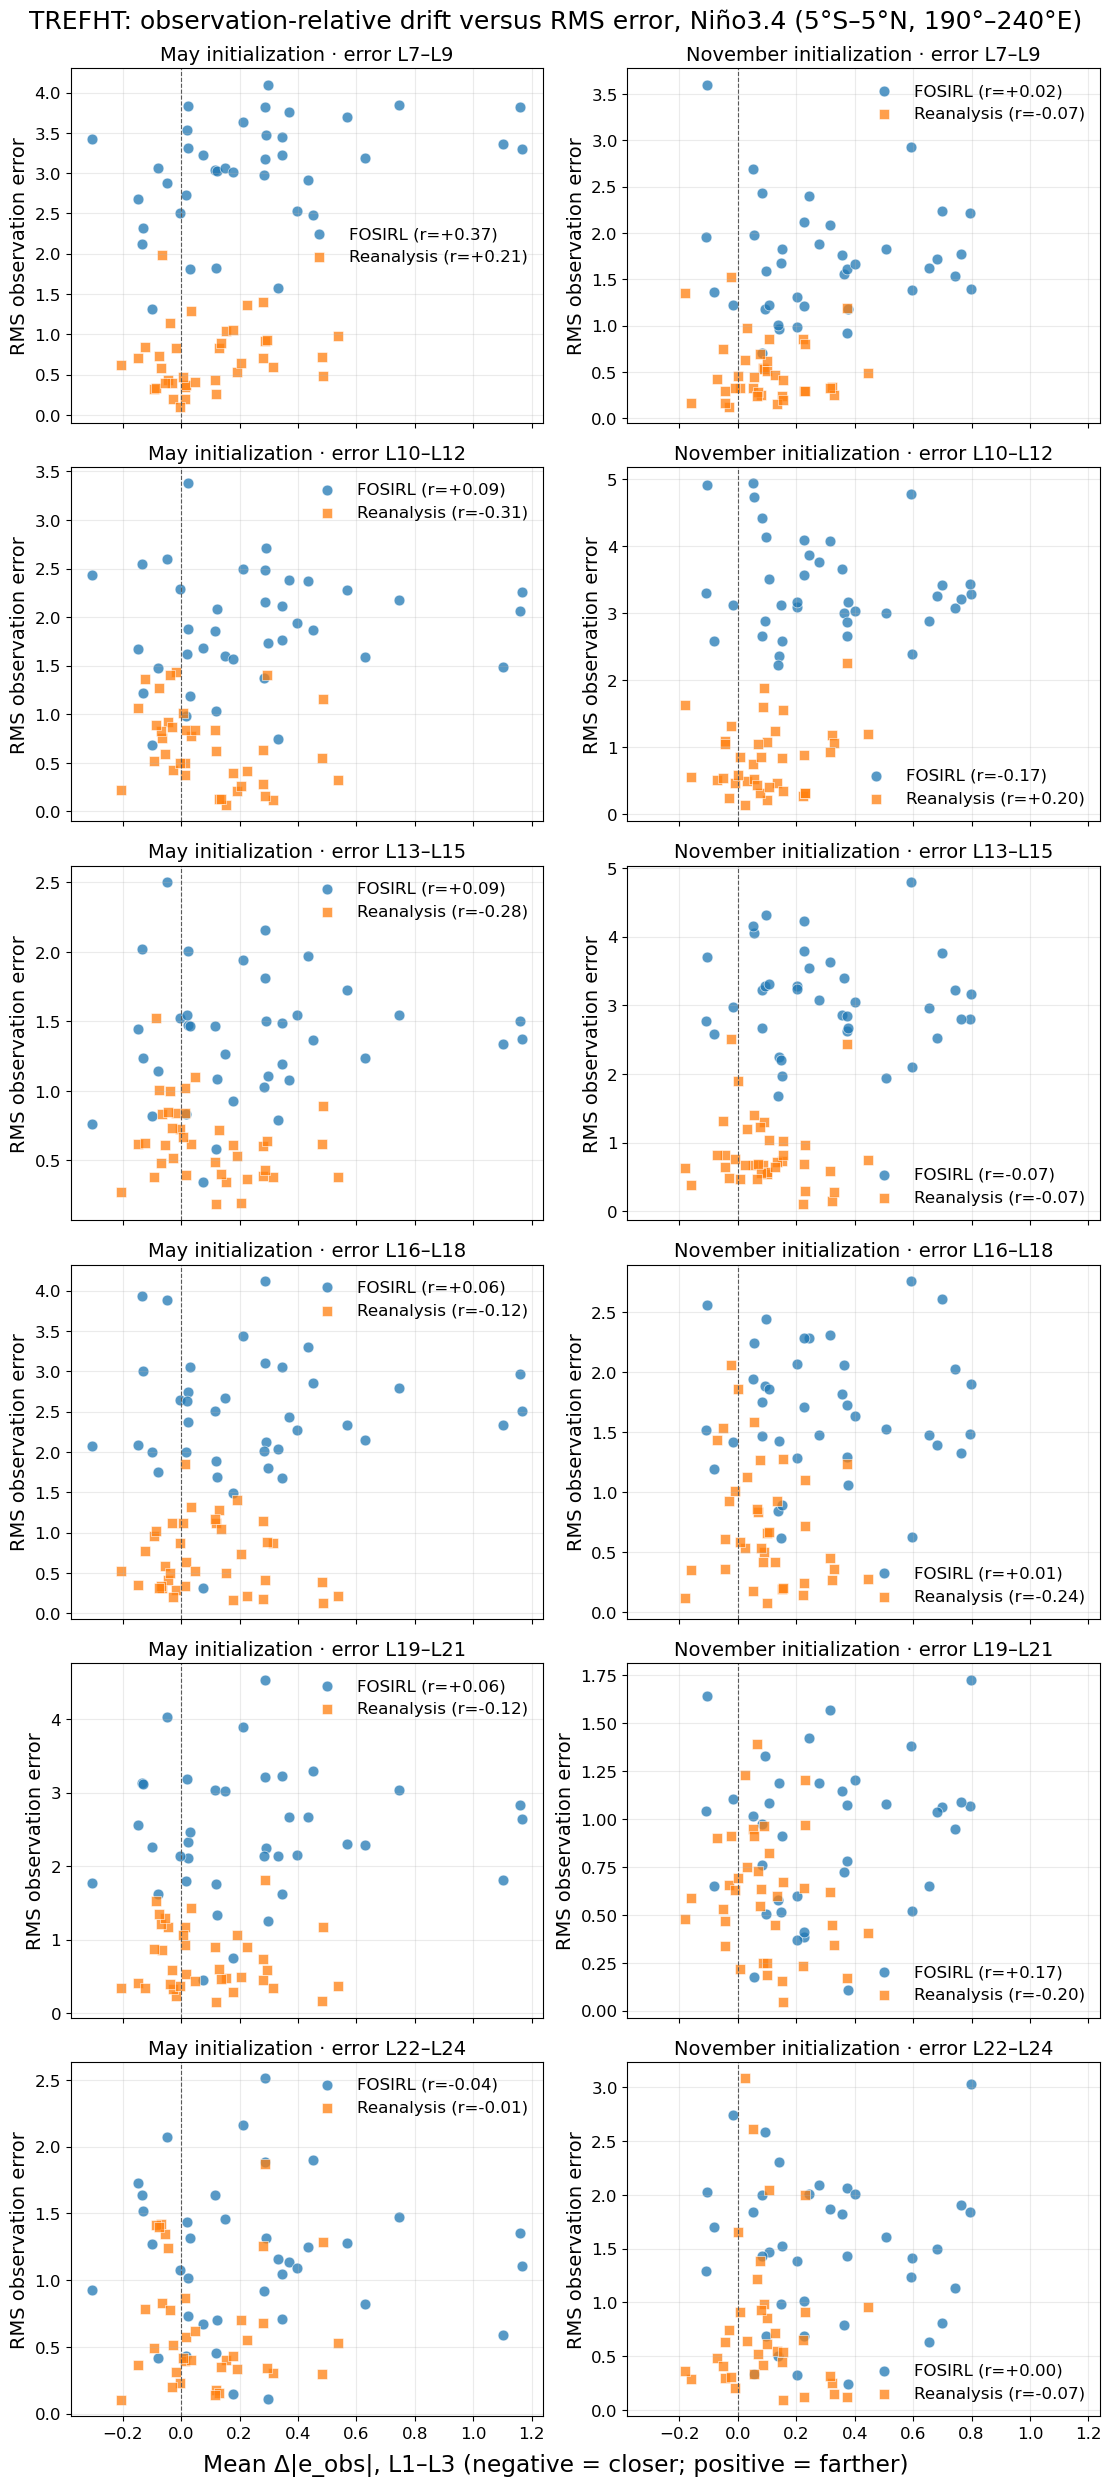

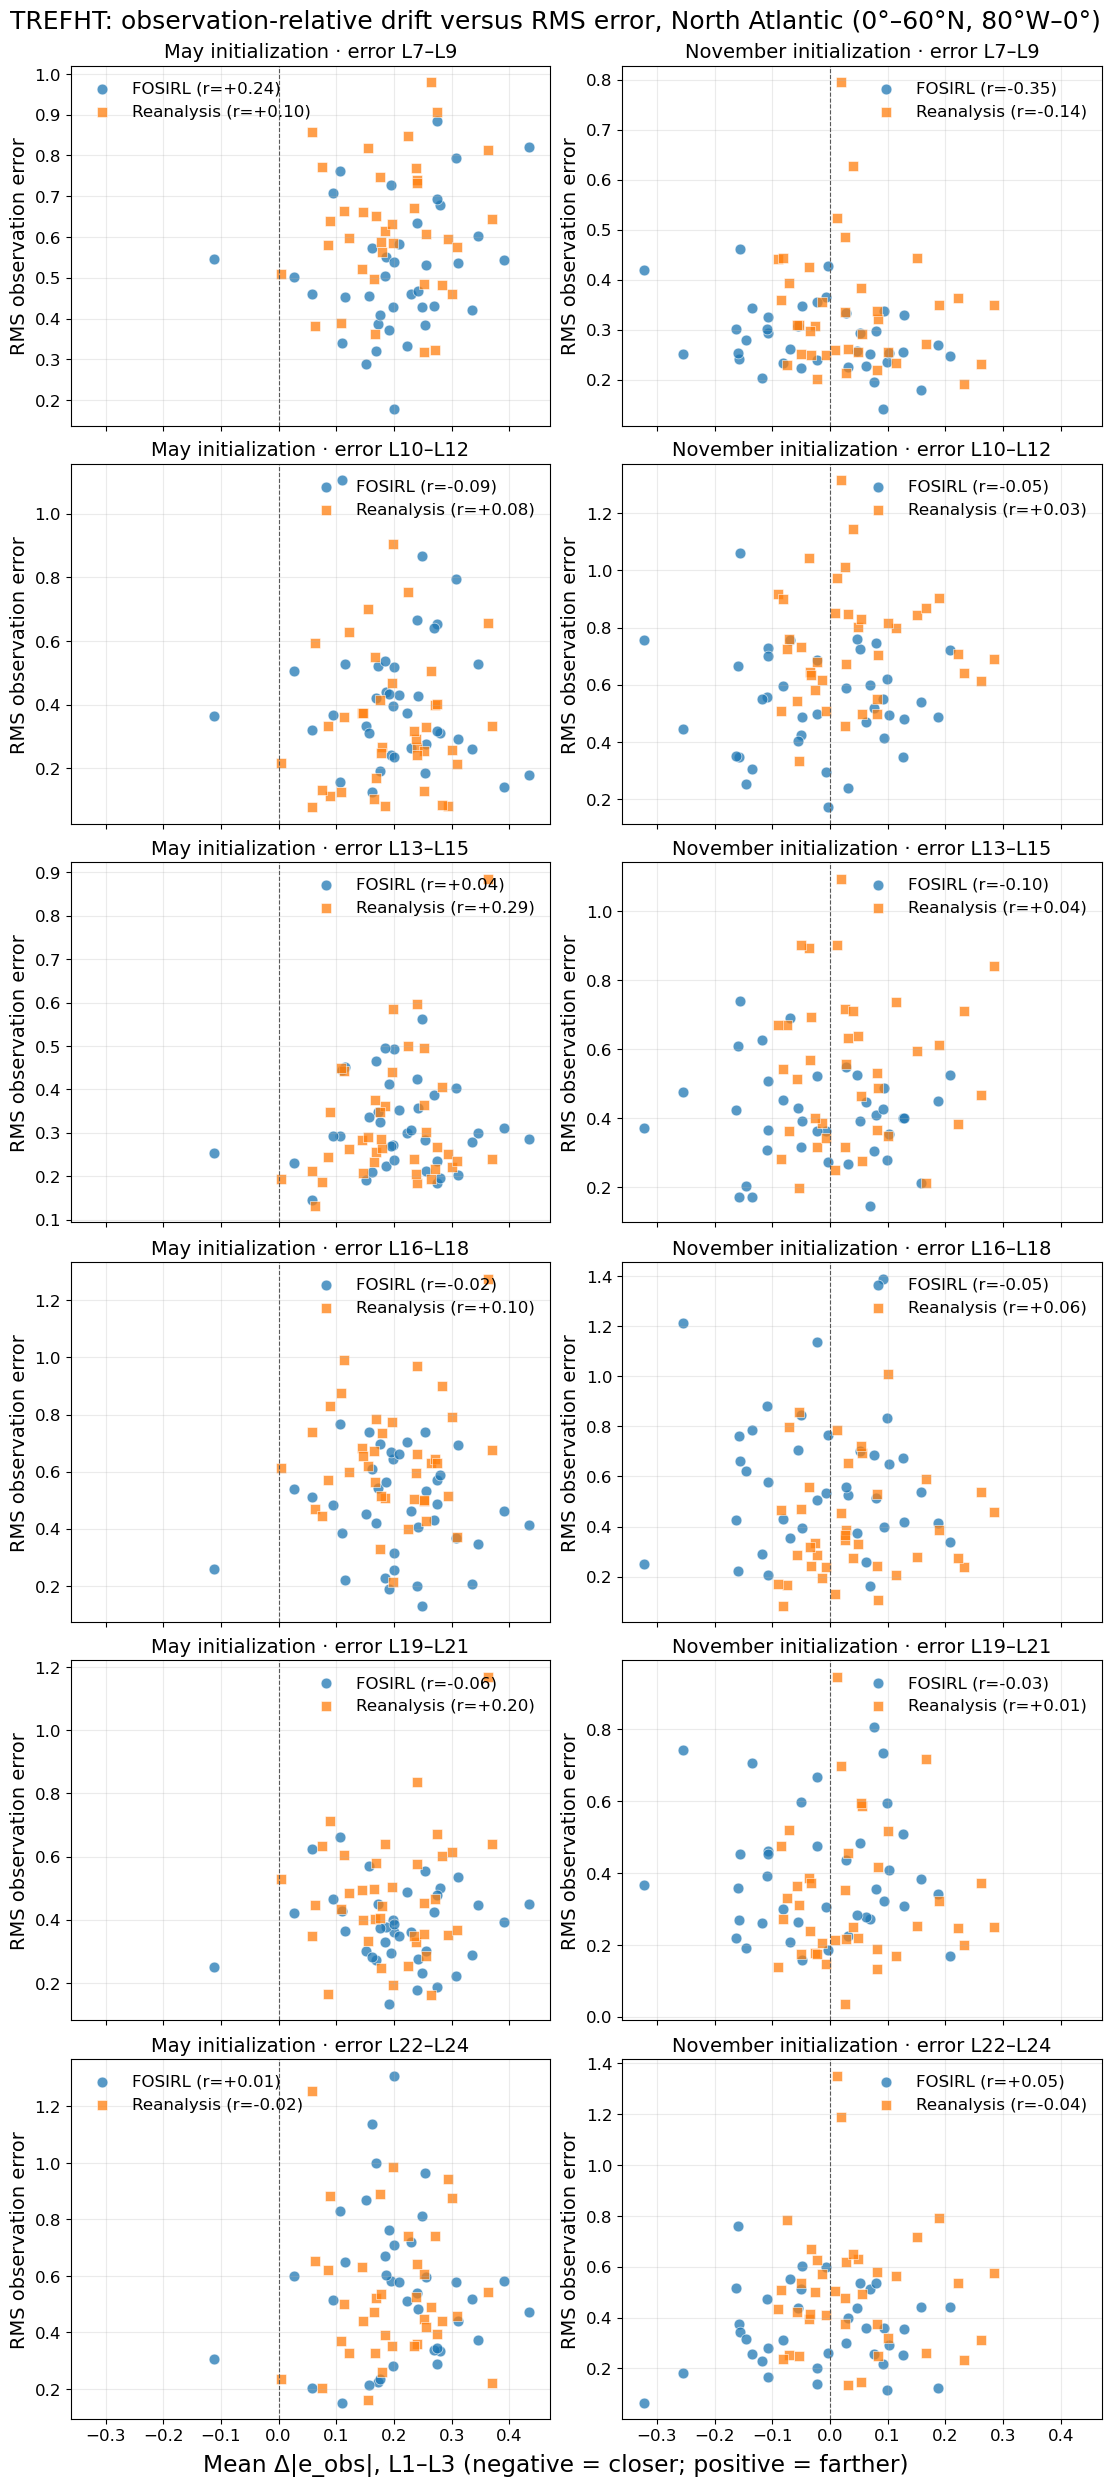

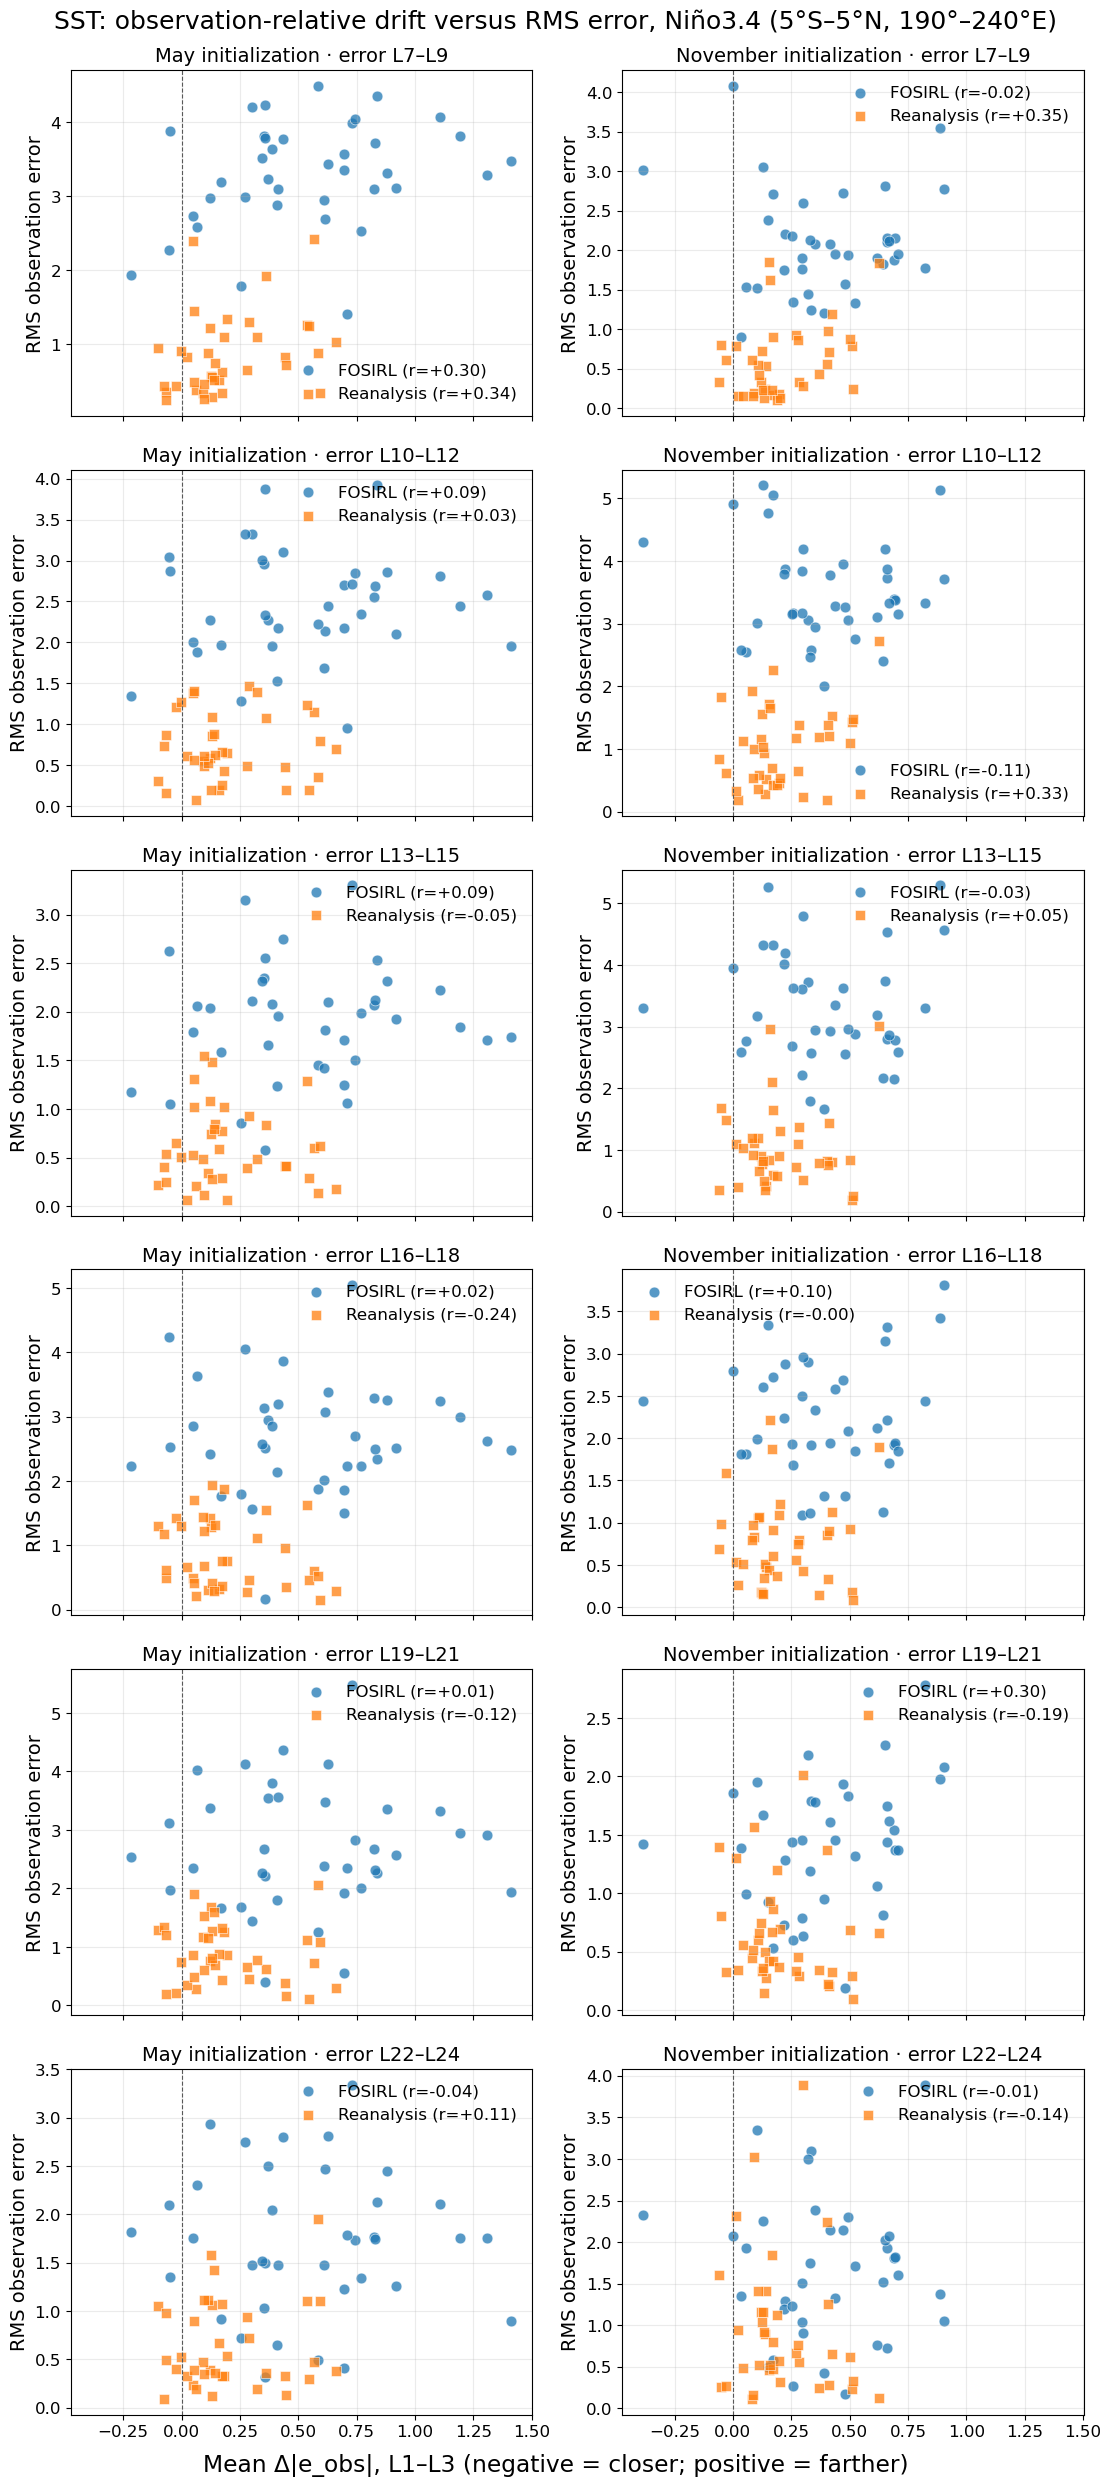

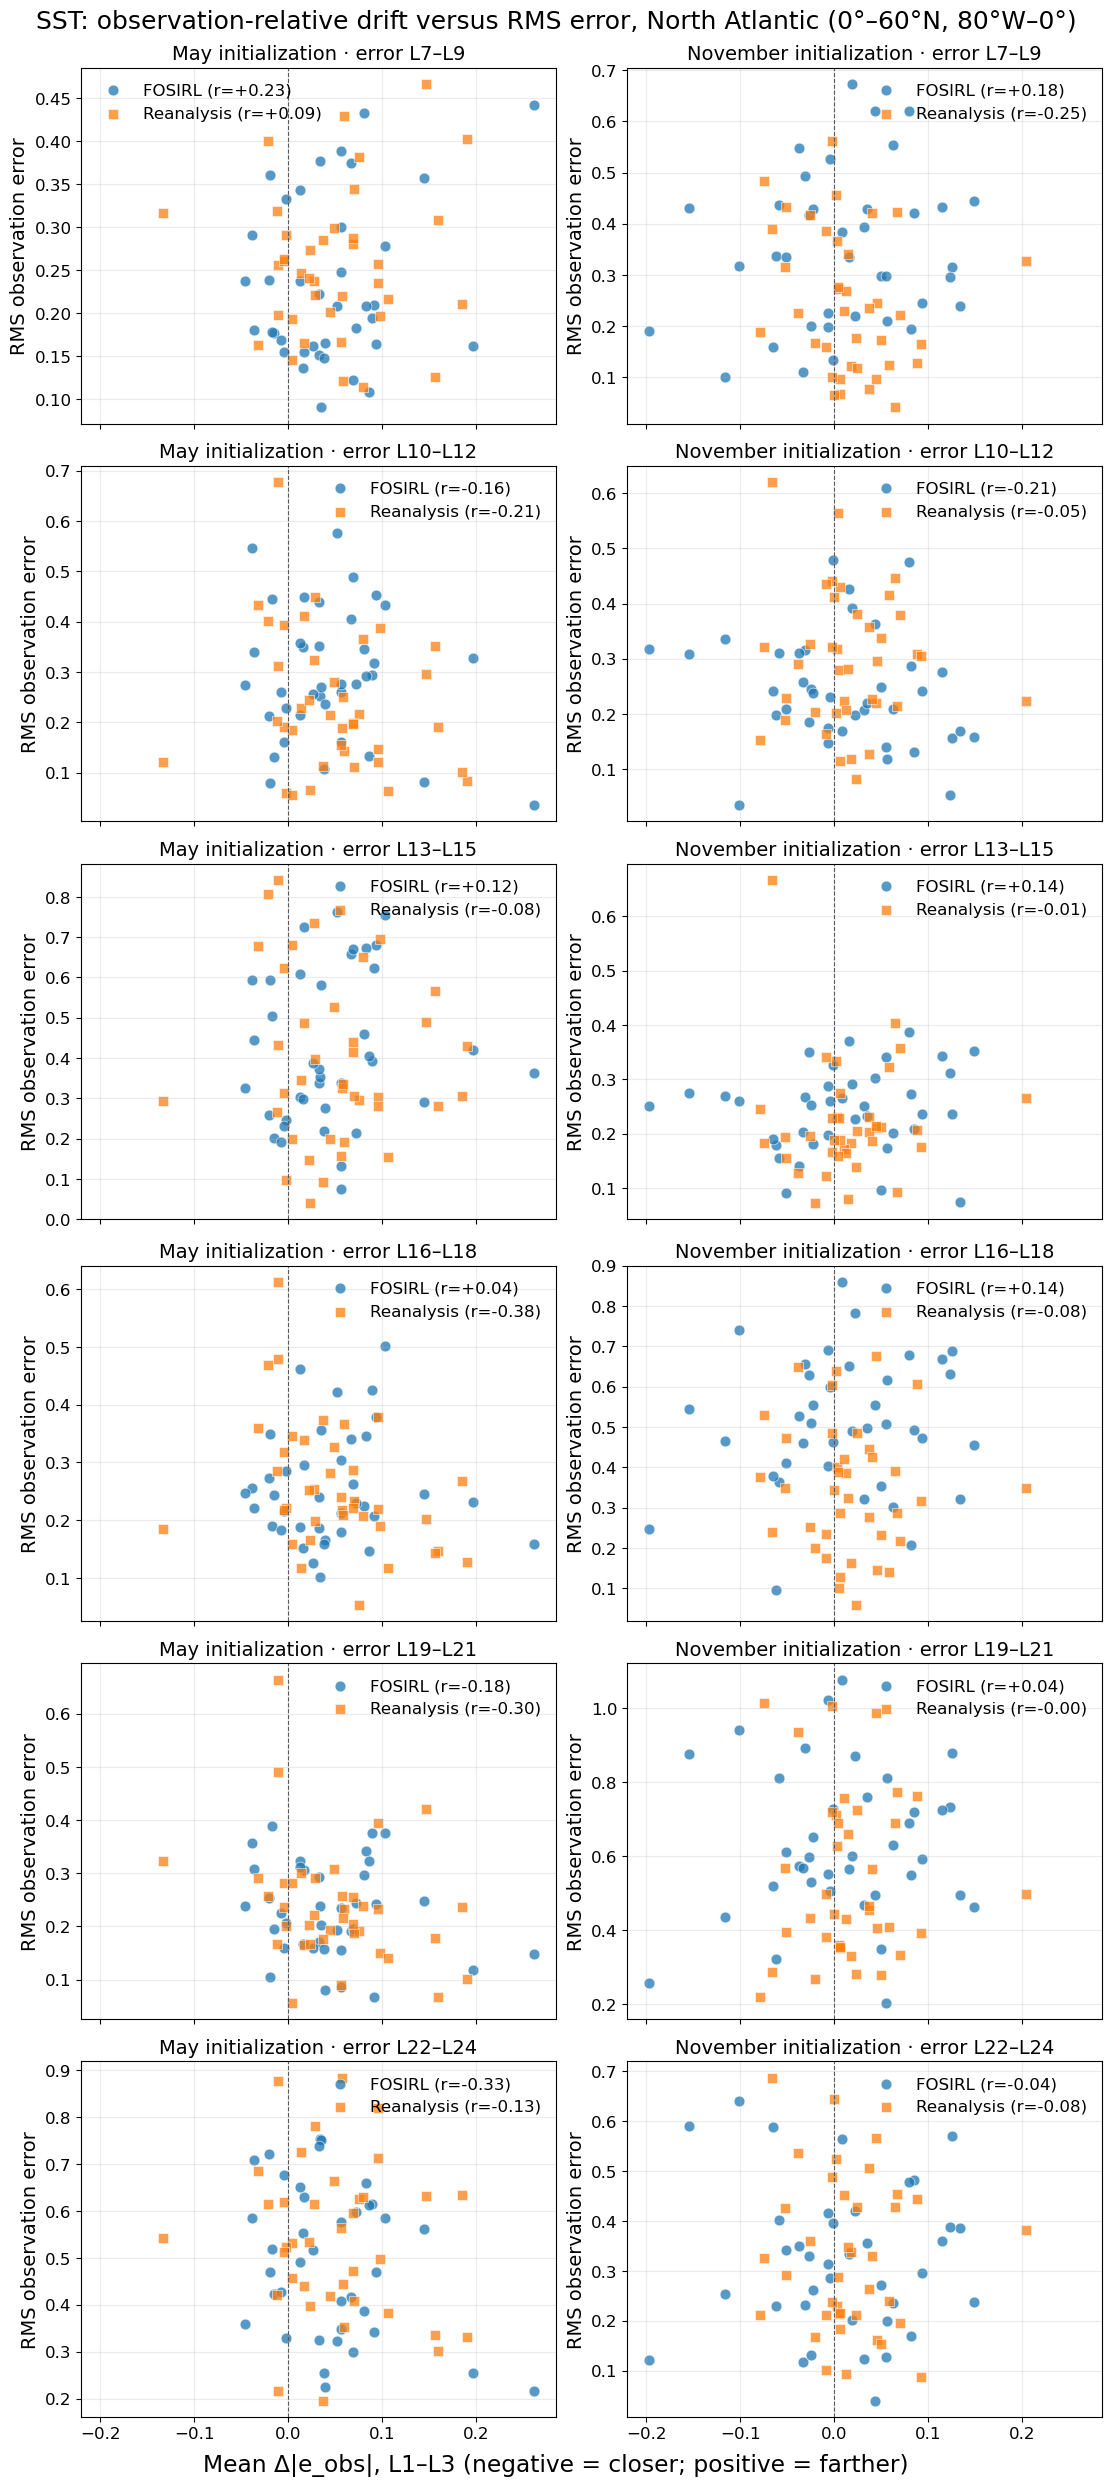

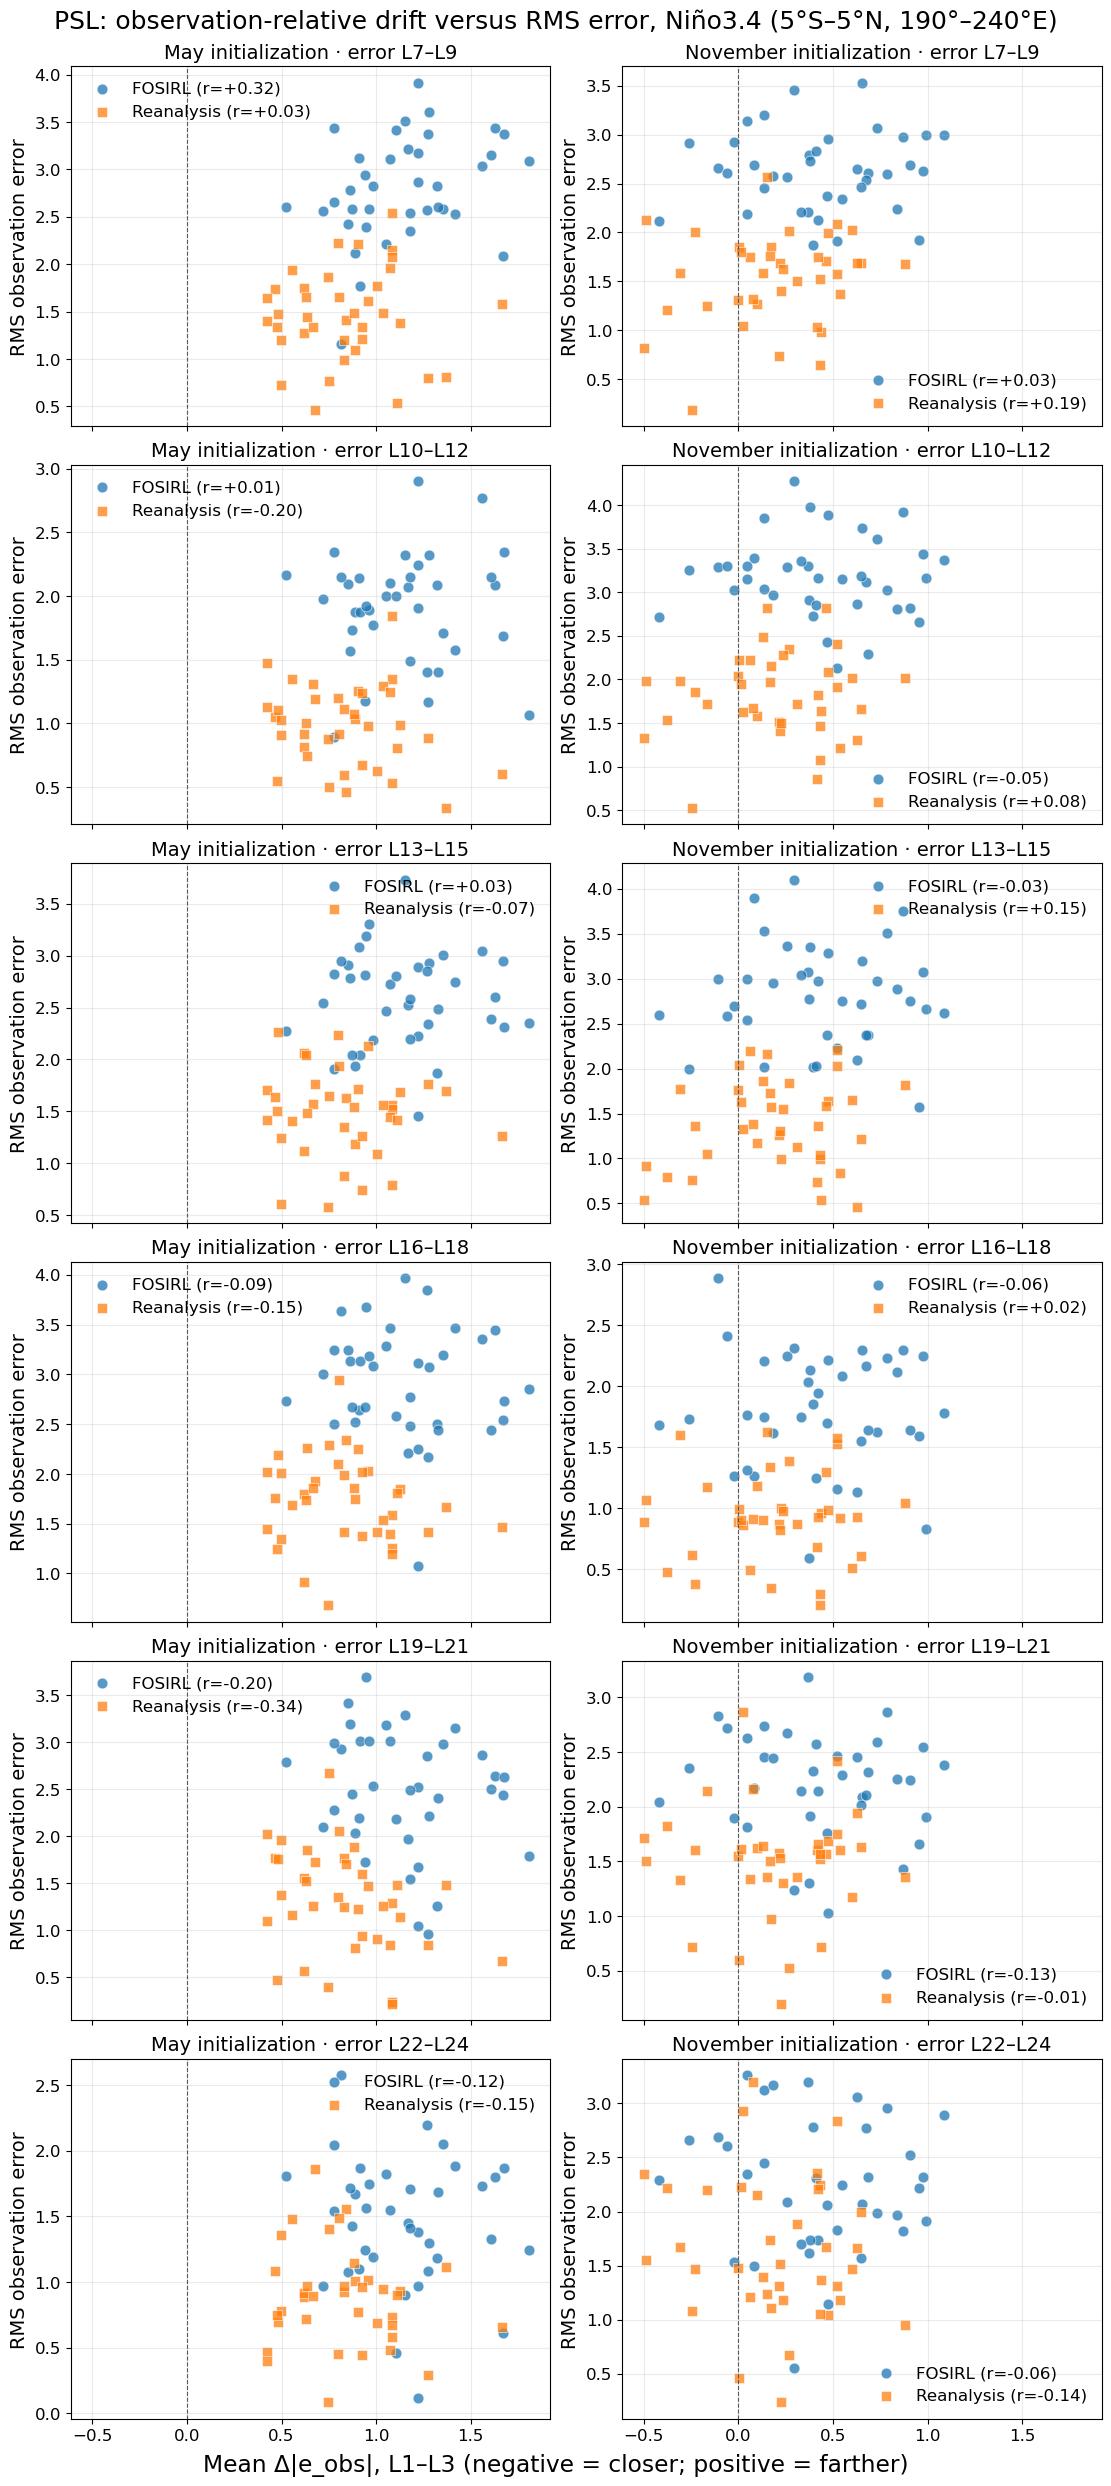

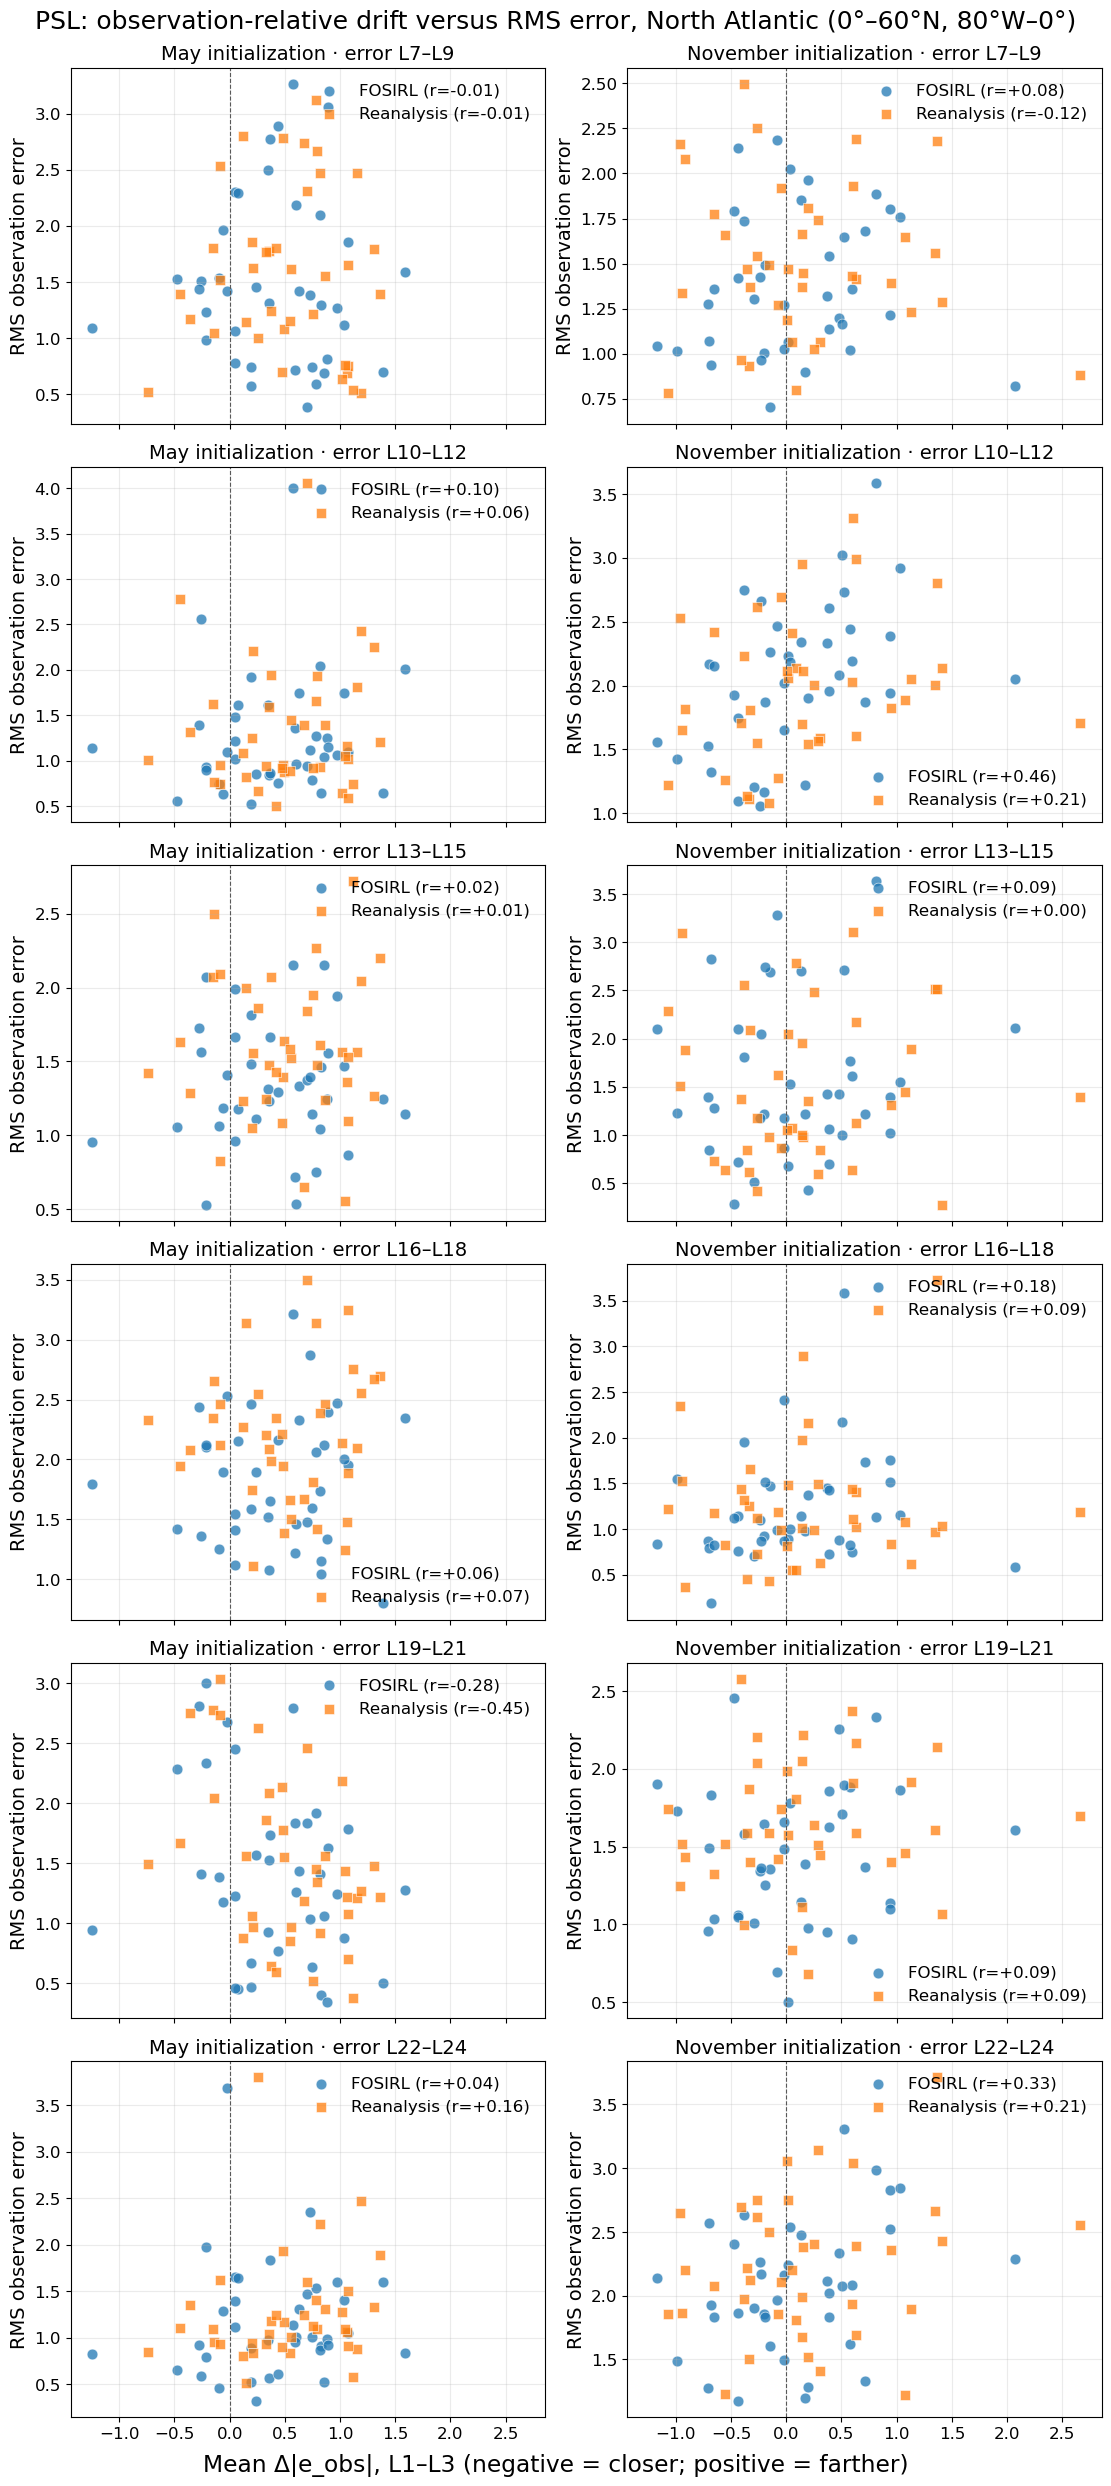

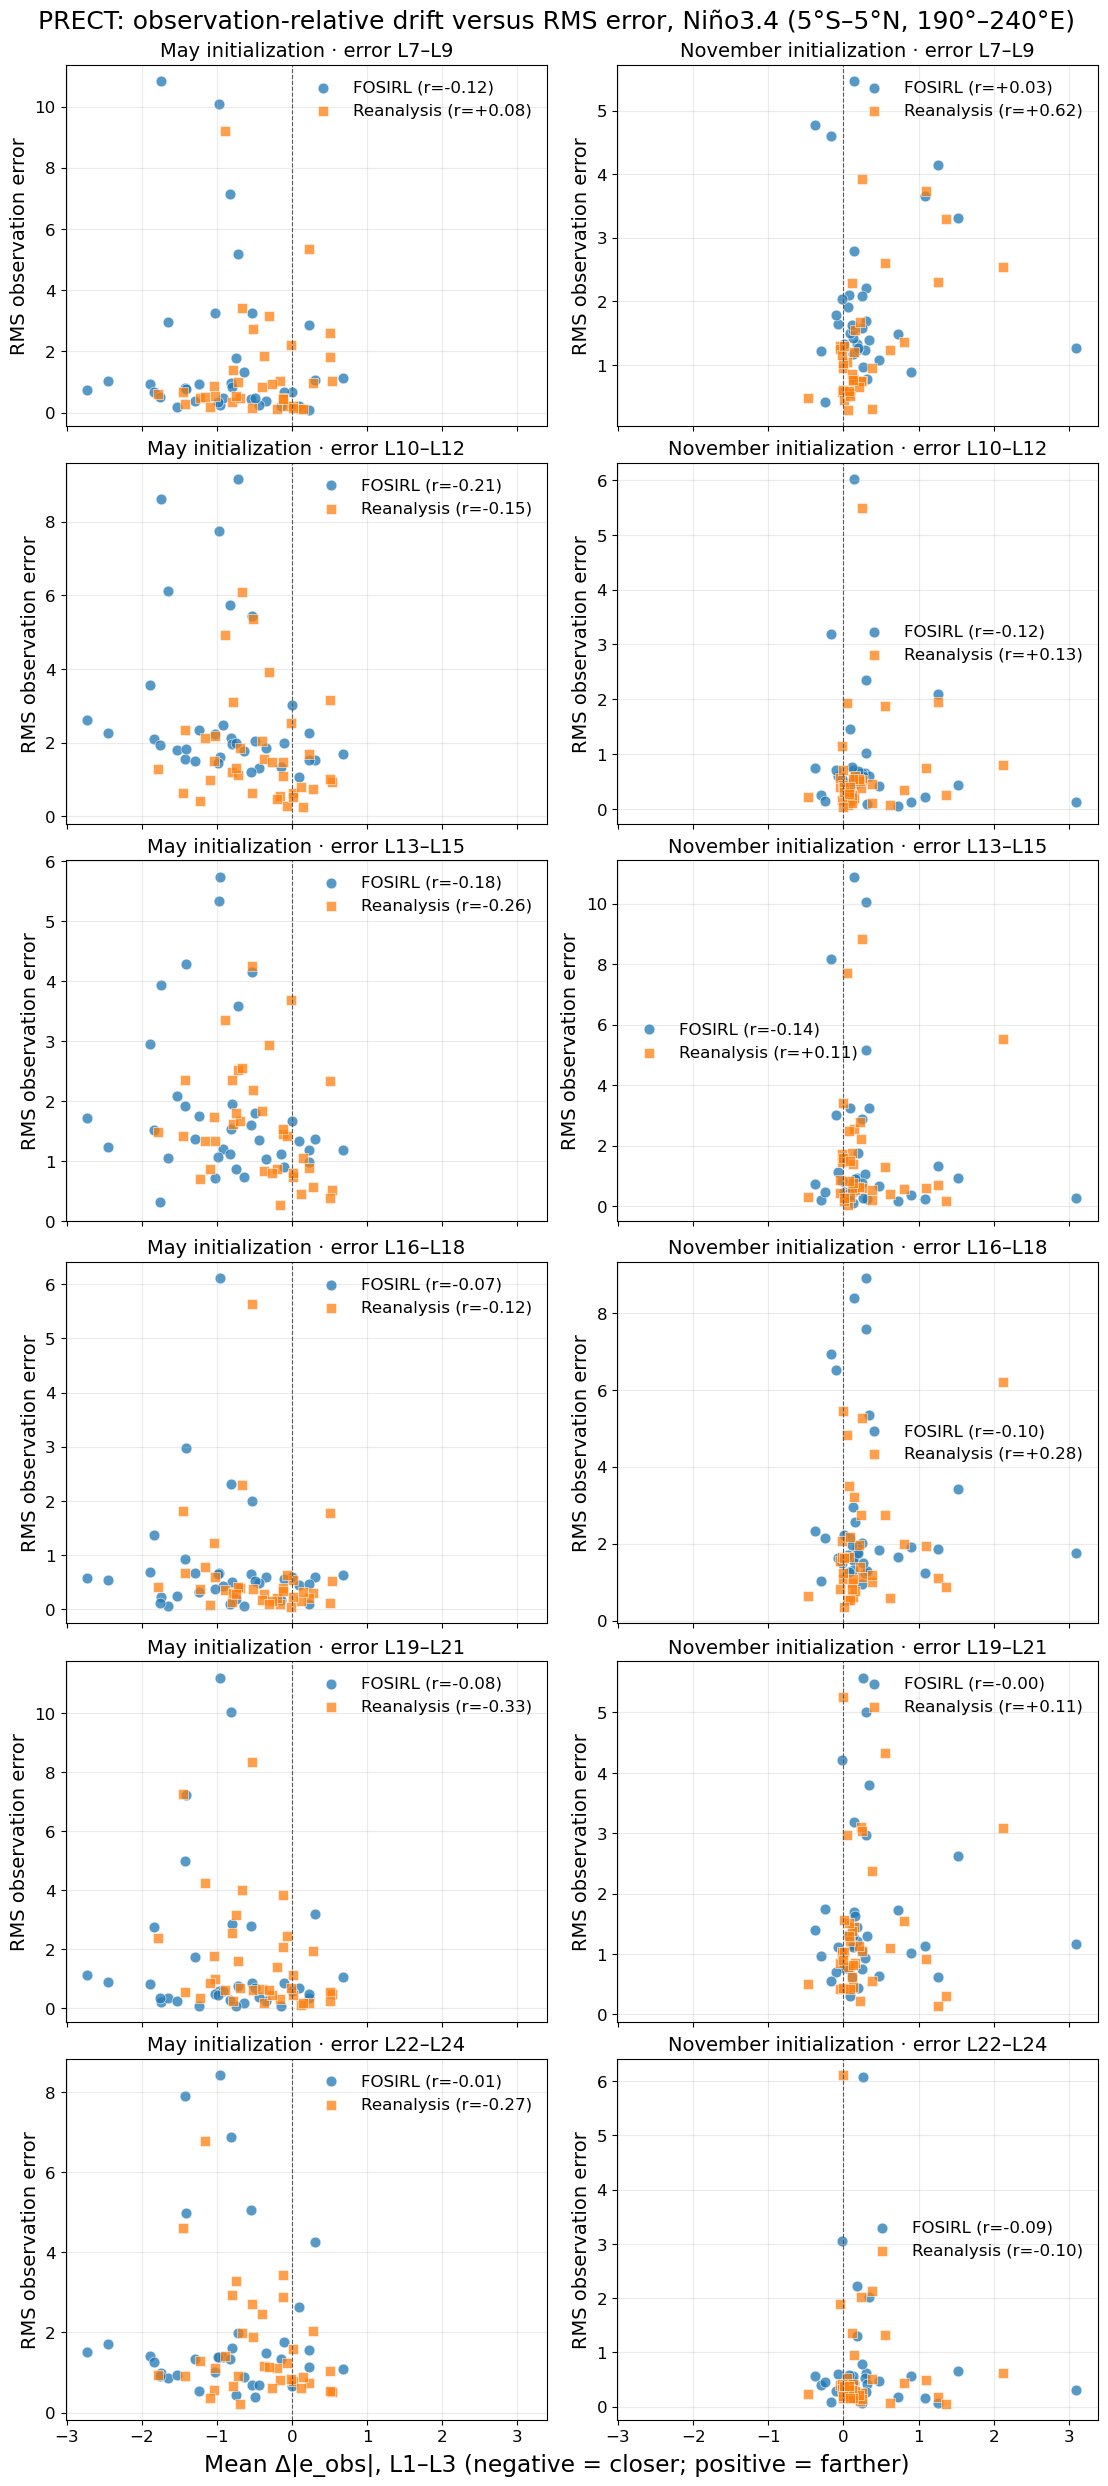

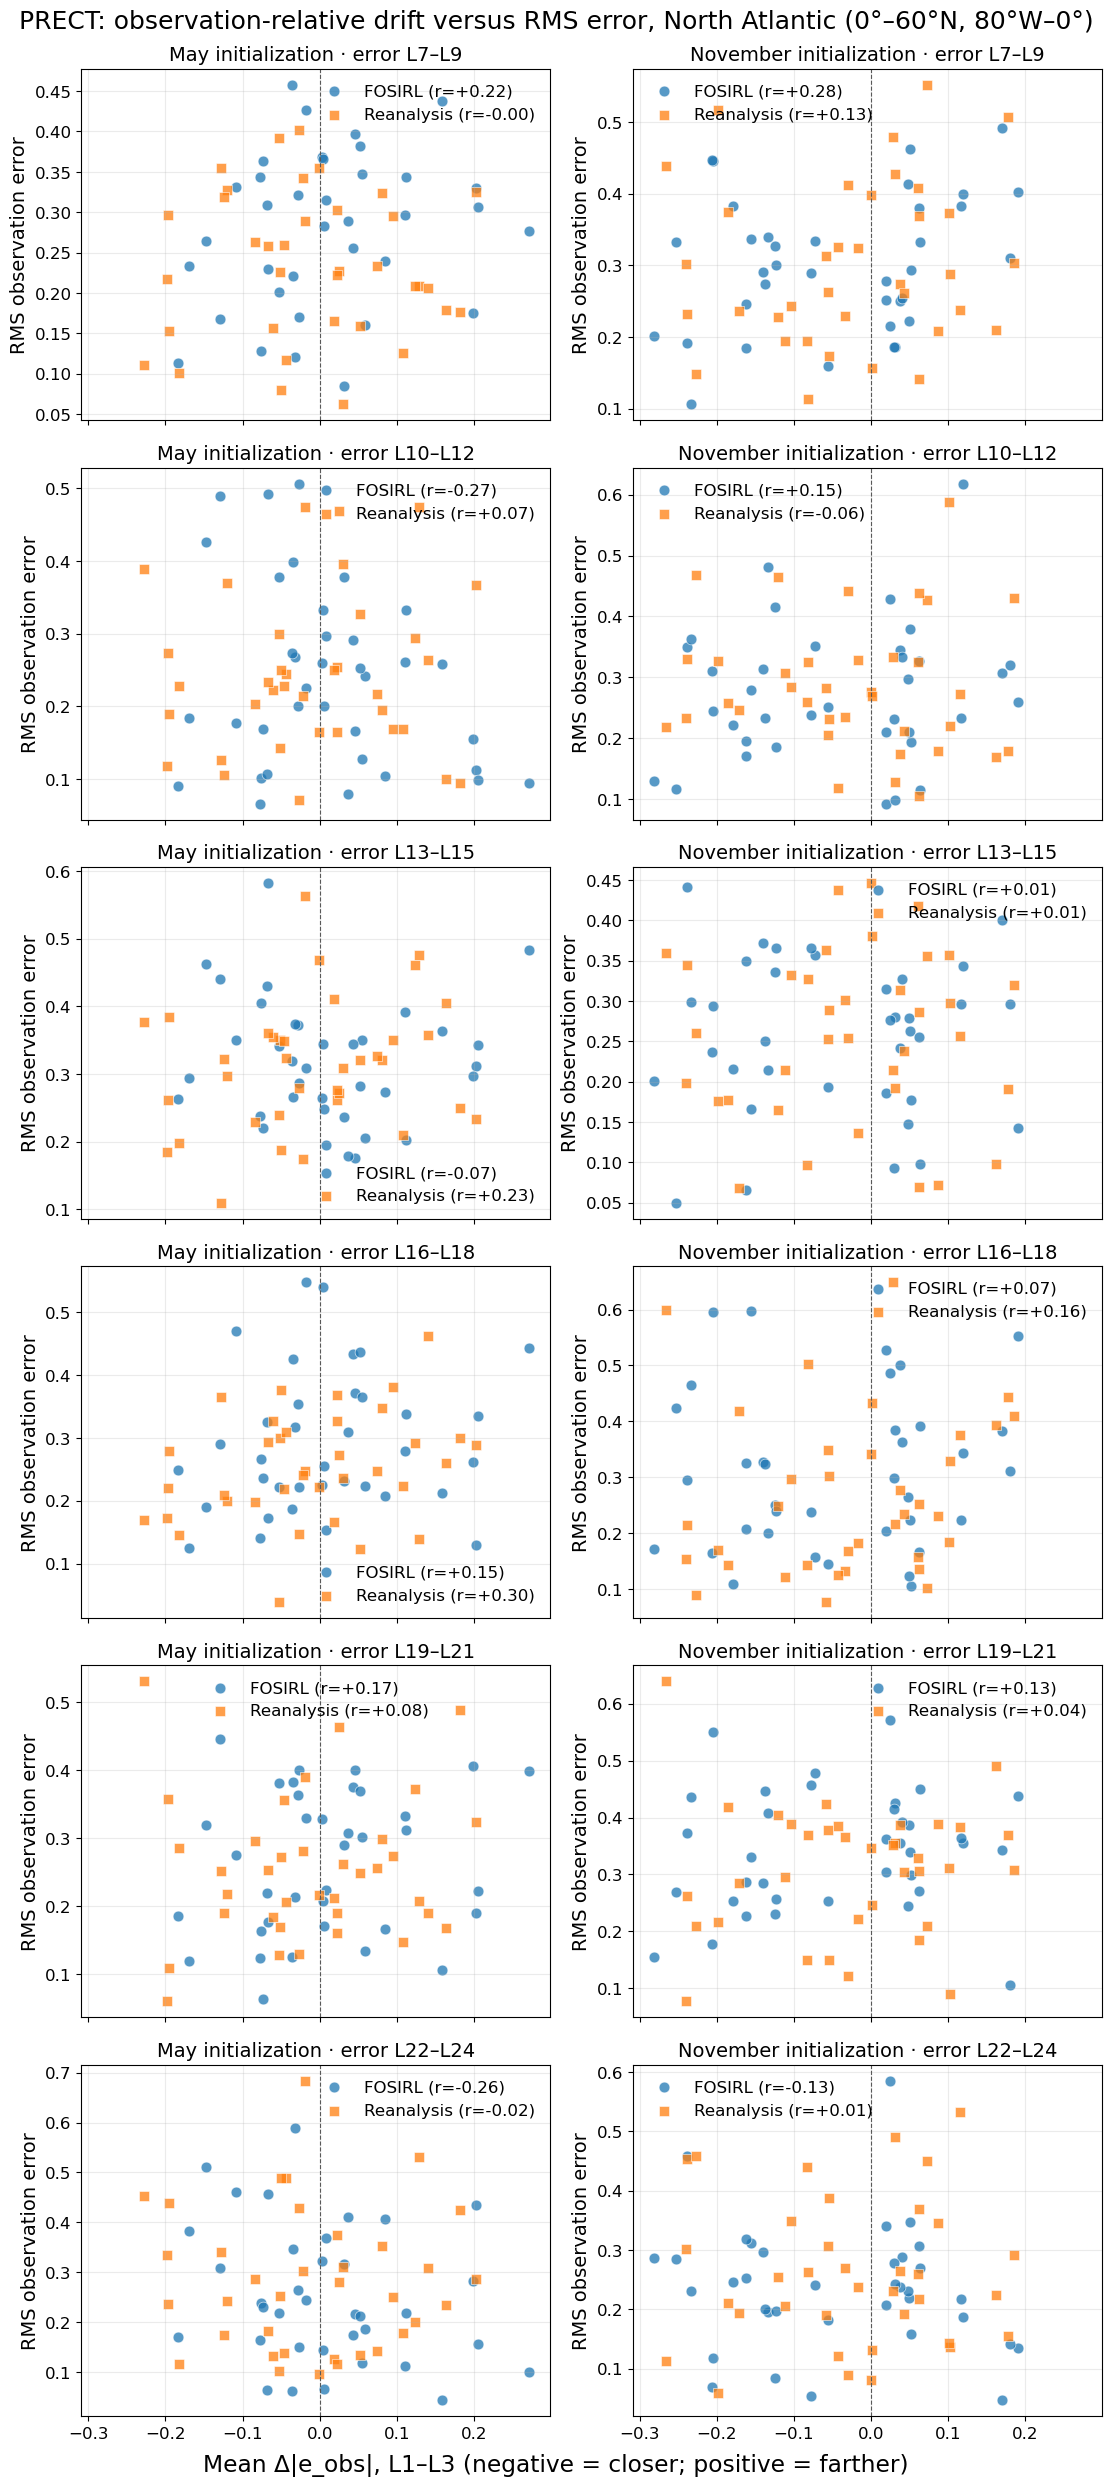

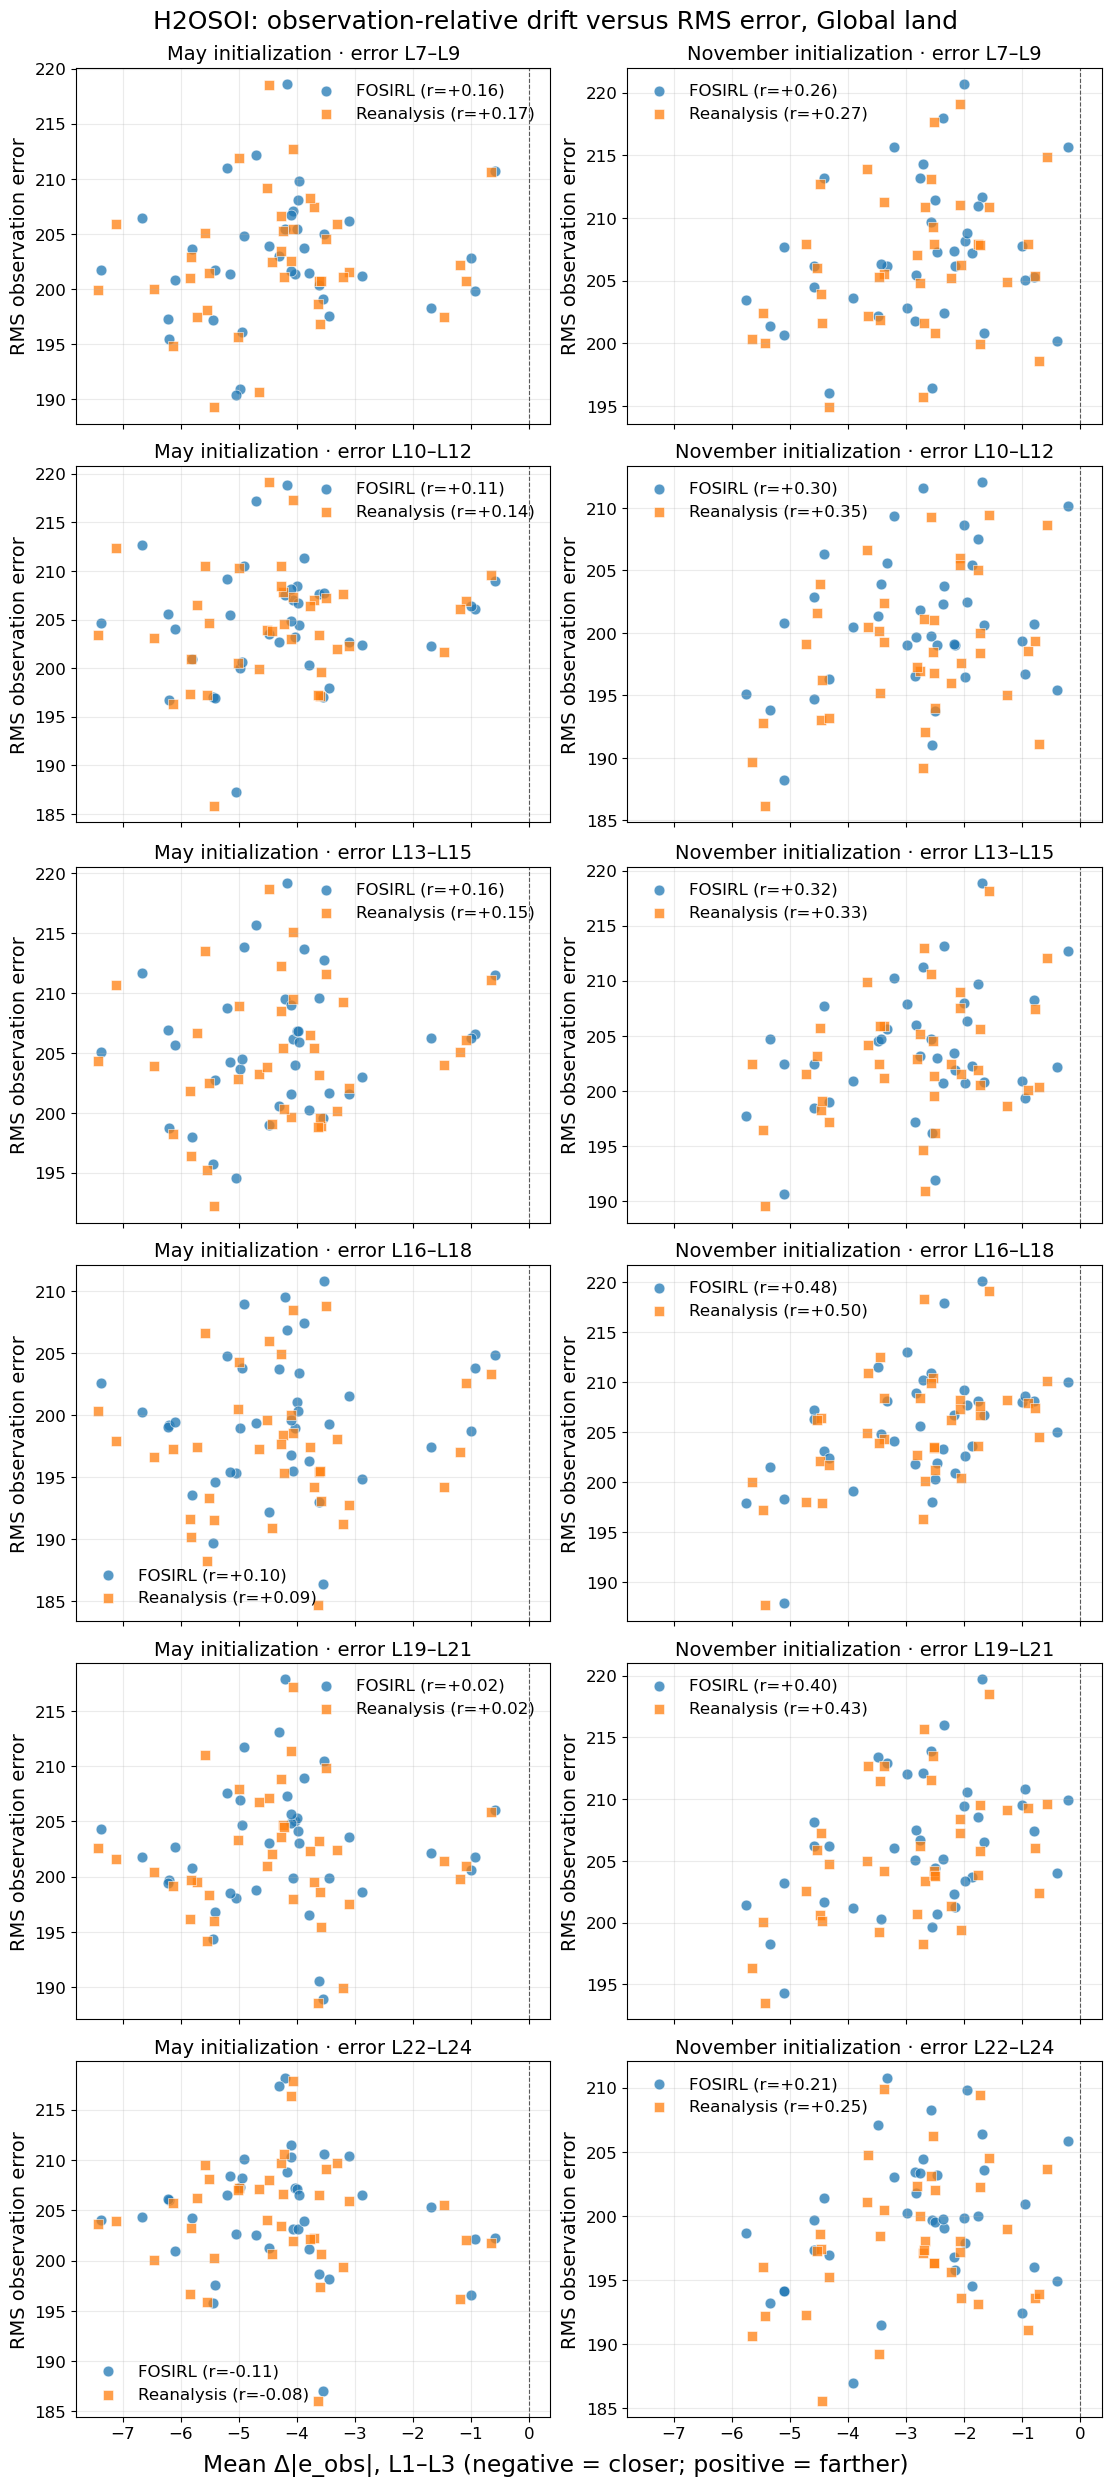

,variable,region,init_month,source,early_leads,late_leads,correlation,n_starts
0,TREFHT,Nino3.4,5,JRA55_FOSIRL,L1–L3,L7–L9,0.373,38
1,TREFHT,Nino3.4,5,Reanalysis,L1–L3,L7–L9,0.207,38
2,TREFHT,Nino3.4,11,JRA55_FOSIRL,L1–L3,L7–L9,0.015,38
3,TREFHT,Nino3.4,11,Reanalysis,L1–L3,L7–L9,-0.067,38
4,TREFHT,Nino3.4,5,JRA55_FOSIRL,L1–L3,L10–L12,0.092,38
...,...,...,...,...,...,...,...,...
211,H2OSOI,Global_land,11,Reanalysis,L1–L3,L19–L21,0.428,38
212,H2OSOI,Global_land,5,JRA55_FOSIRL,L1–L3,L22–L24,-0.108,38
213,H2OSOI,Global_land,5,Reanalysis,L1–L3,L22–L24,-0.085,38
214,H2OSOI,Global_land,11,JRA55_FOSIRL,L1–L3,L22–L24,0.213,38


/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_drift_skill_correlations.csv


In [30]:
def finite_xy(relationship):
    x = np.asarray(relationship.early_drift).reshape(-1)
    y = np.asarray(relationship.late_error).reshape(-1)
    finite = np.isfinite(x) & np.isfinite(y)
    return x[finite], y[finite]


figure_paths = []
correlation_rows = []
for variable in VARIABLES:
    for region_name in PLOT_REGIONS[variable]:
        fig, axes = plt.subplots(
            len(LATE_ERROR_WINDOWS), len(INIT_MONTHS),
            figsize=figure_size(), sharex=True, squeeze=False,
            constrained_layout=True,
        )
        for row, late_leads in enumerate(LATE_ERROR_WINDOWS):
            for col, init_month in enumerate(INIT_MONTHS):
                ax = axes[row, col]
                for source in SOURCES:
                    fields = drift_skill_inputs[(
                        variable, init_month, source
                    )].sel(region=region_name)
                    relationship = compute_early_drift_late_error(
                        fields.delta_abs_e_obs, fields.e_obs,
                        early_leads=EARLY_LEADS, late_leads=late_leads,
                    )
                    x, y = finite_xy(relationship)
                    correlation = float(relationship.correlation)
                    ax.scatter(
                        x, y, s=SCATTER_SIZE, alpha=SCATTER_ALPHA,
                        marker=SOURCE_MARKERS[source],
                        color=SOURCE_COLORS[source],
                        edgecolor='white', linewidth=0.5,
                        label=(
                            f'{SOURCE_LABELS[source]} '
                            f'(r={correlation:+.2f})'
                        ),
                    )
                    correlation_rows.append({
                        'variable': variable, 'region': region_name,
                        'init_month': init_month, 'source': source,
                        'early_leads': lead_window_label(EARLY_LEADS),
                        'late_leads': lead_window_label(late_leads),
                        'correlation': correlation, 'n_starts': x.size,
                    })
                ax.axvline(0, color='0.35', linewidth=0.8, linestyle='--')
                ax.set_title(
                    f'{MONTH_NAMES[init_month]} initialization · '
                    f'error {lead_window_label(late_leads)}'
                )
                ax.set_ylabel('RMS observation error')
                ax.grid(True, alpha=0.25)
                ax.set_box_aspect(
                    PANEL_ASPECT_RATIO[1] / PANEL_ASPECT_RATIO[0]
                )
                ax.legend(frameon=False, loc='best')
        fig.suptitle(
            f'{variable}: observation-relative drift versus RMS error, '
            f'{REGION_LABELS[region_name]}'
        )
        fig.supxlabel(
            f'Mean Δ|e_obs|, {lead_window_label(EARLY_LEADS)} '
            '(negative = closer; positive = farther)'
        )
        path = FIGURE_ROOT / (
            f'{FIGURE_PREFIX}_{variable}_May_Nov_'
            f'{REGION_FILE_LABELS[region_name]}_drift_skill.png'
        )
        fig.savefig(path, dpi=FIGURE_DPI, bbox_inches='tight')
        if SHOW_FIGURES_INLINE:
            display(fig)
        plt.close(fig)
        figure_paths.append(path)

correlation_table = pd.DataFrame(correlation_rows)
correlation_path = FIGURE_ROOT / (
    f'{FIGURE_PREFIX}_drift_skill_correlations.csv'
)
correlation_table.to_csv(correlation_path, index=False)
display(correlation_table.round({'correlation': 3}))
print(correlation_path)

## 7. Paired strategy contrast

For the same initialization year $k$, this diagnostic compares

$$\Delta D_k=D_{\mathrm{FOSIRL},k}-D_{\mathrm{Reanalysis},k}$$

against

$$\Delta E_k=E_{\mathrm{FOSIRL},k}-E_{\mathrm{Reanalysis},k}.$$

The lower-left quadrant means FOSIRL has both smaller early drift and smaller later error; the upper-right means Reanalysis wins on both. The annotation gives the paired Pearson correlation with a paired-year bootstrap confidence interval and the fraction of starts for which the two differences have the same sign.

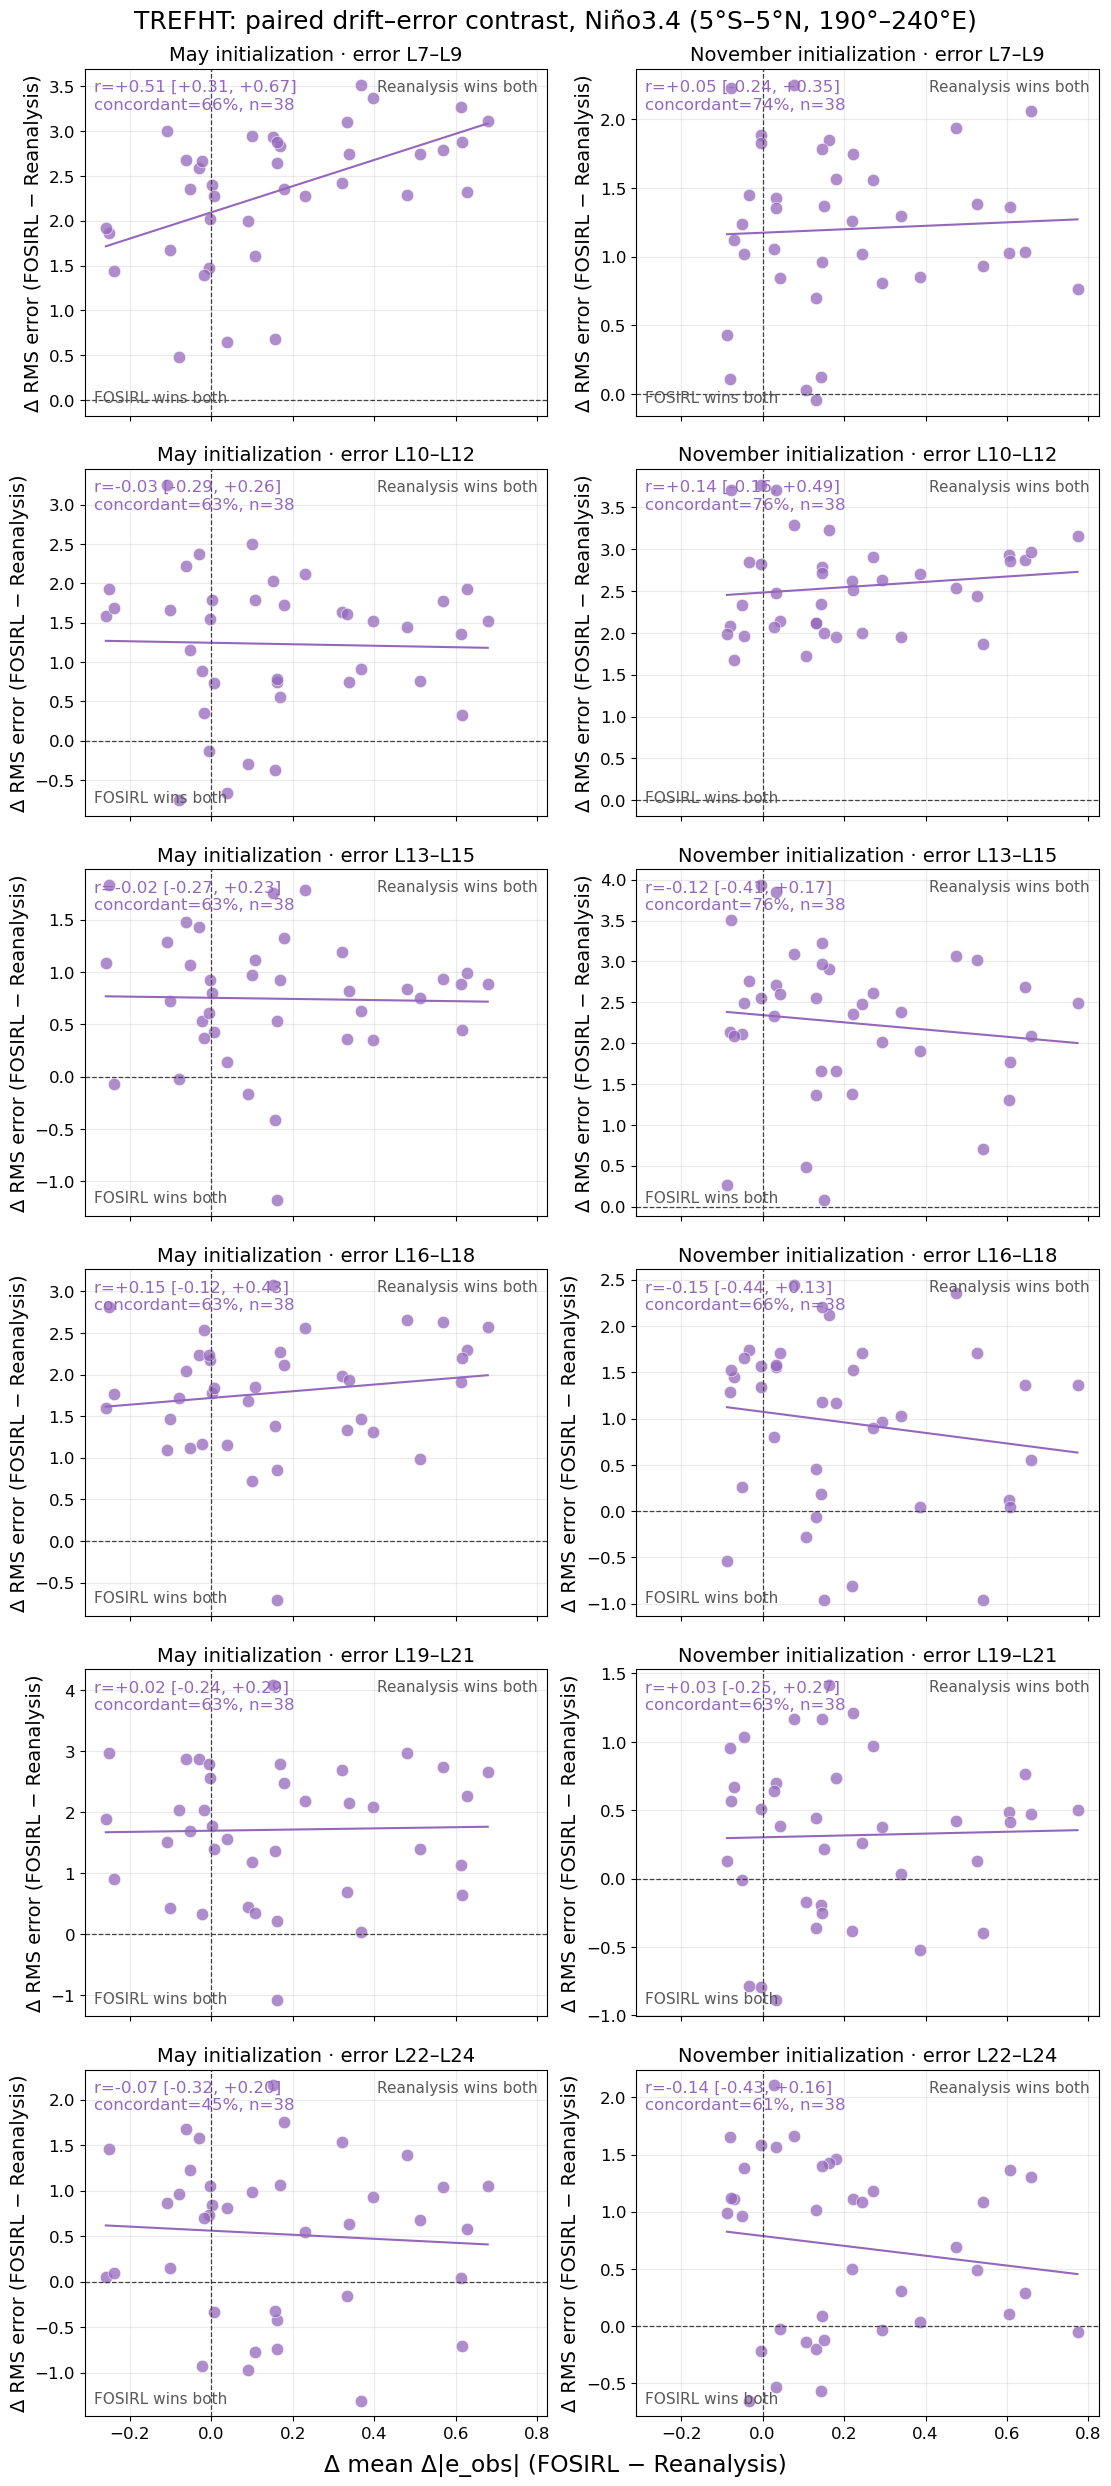

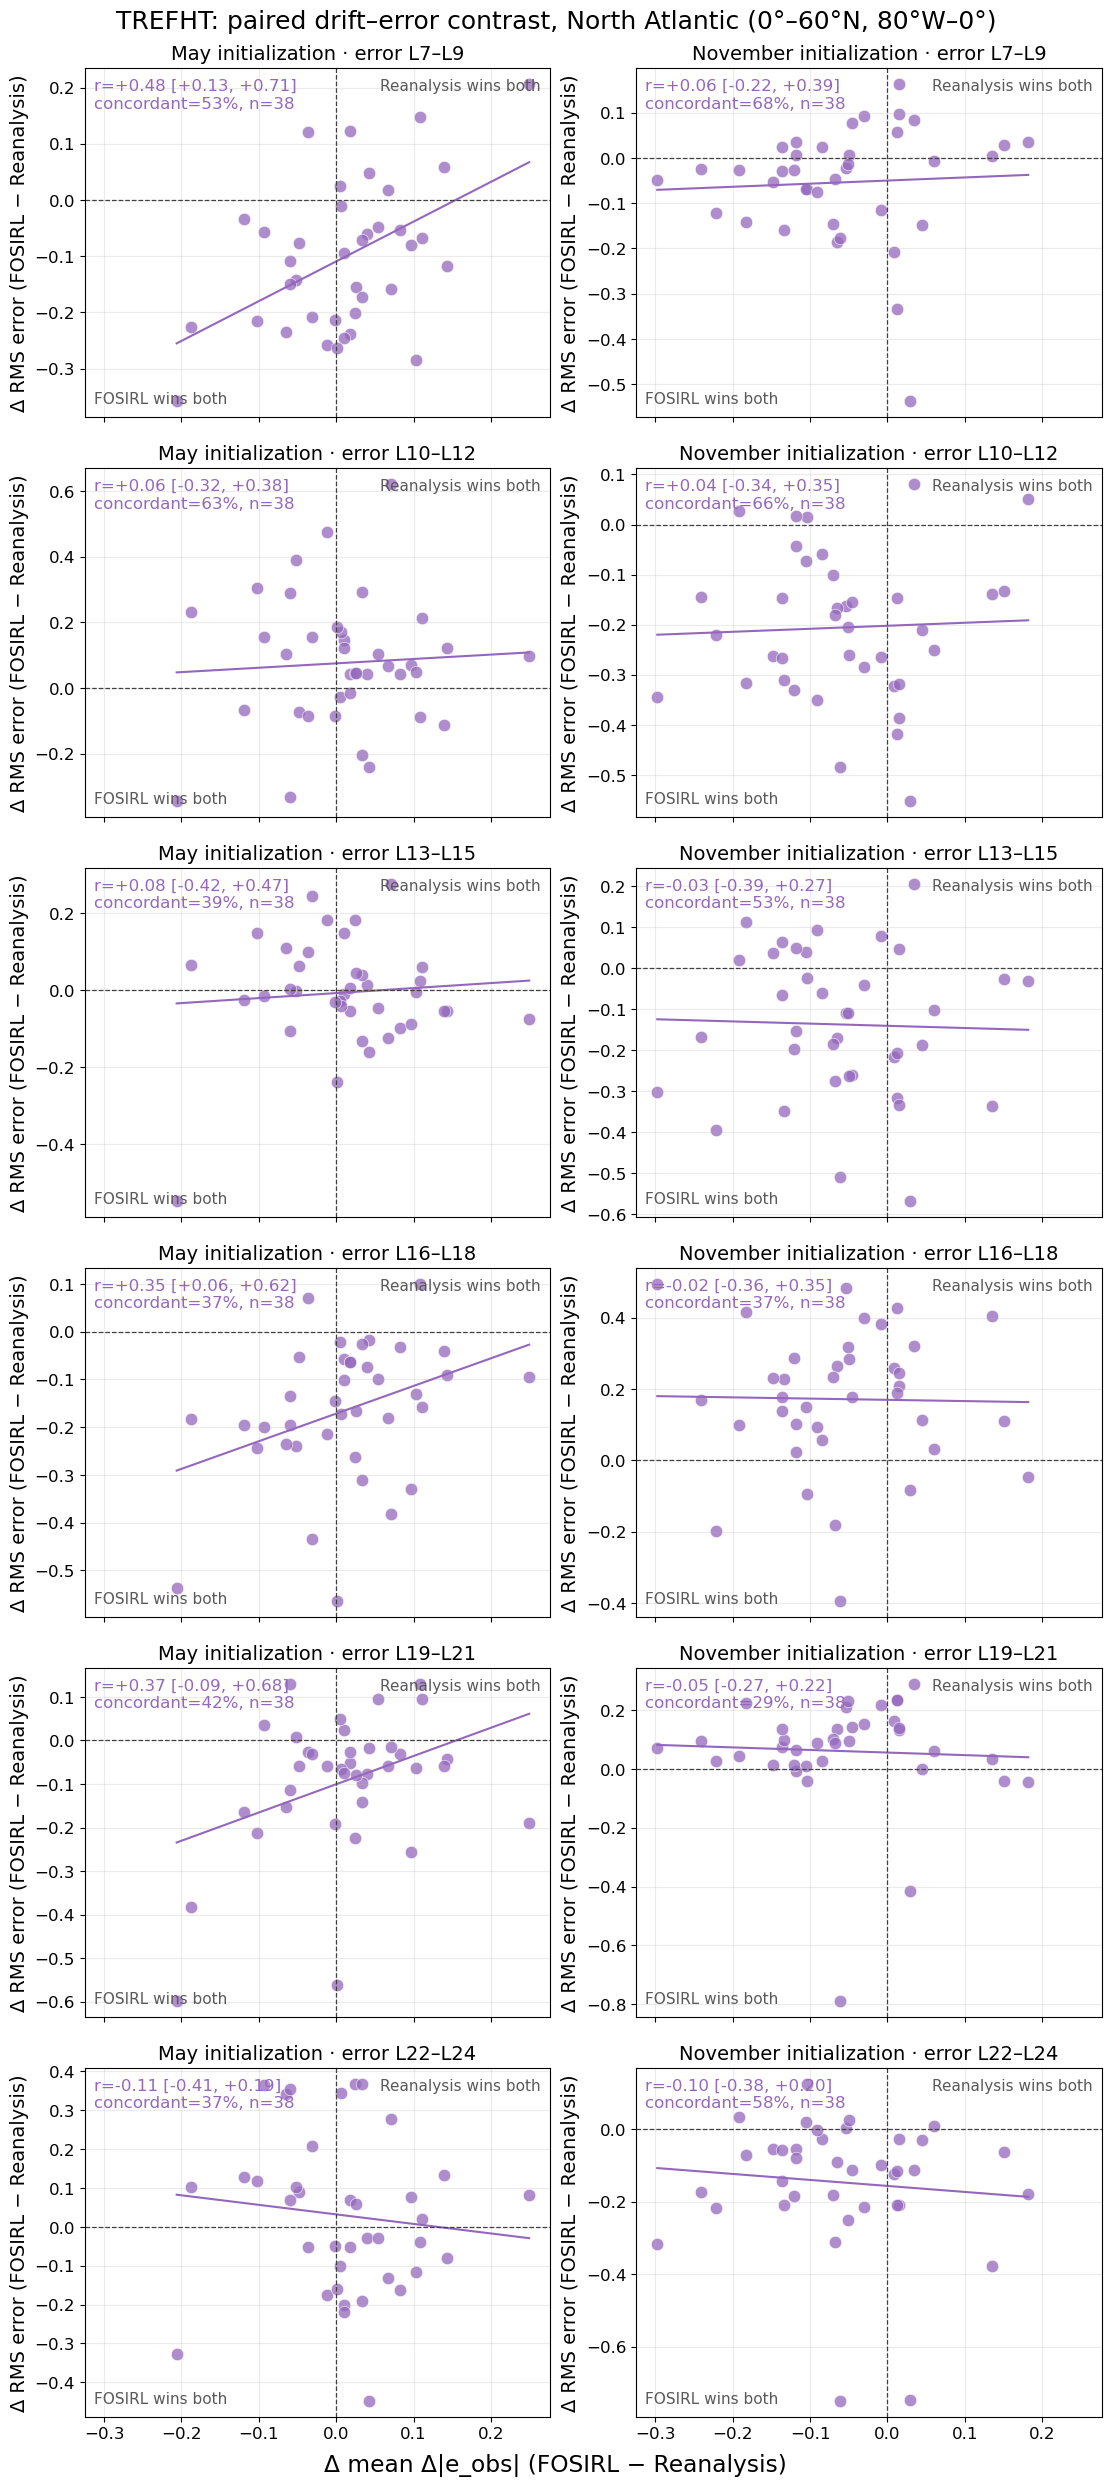

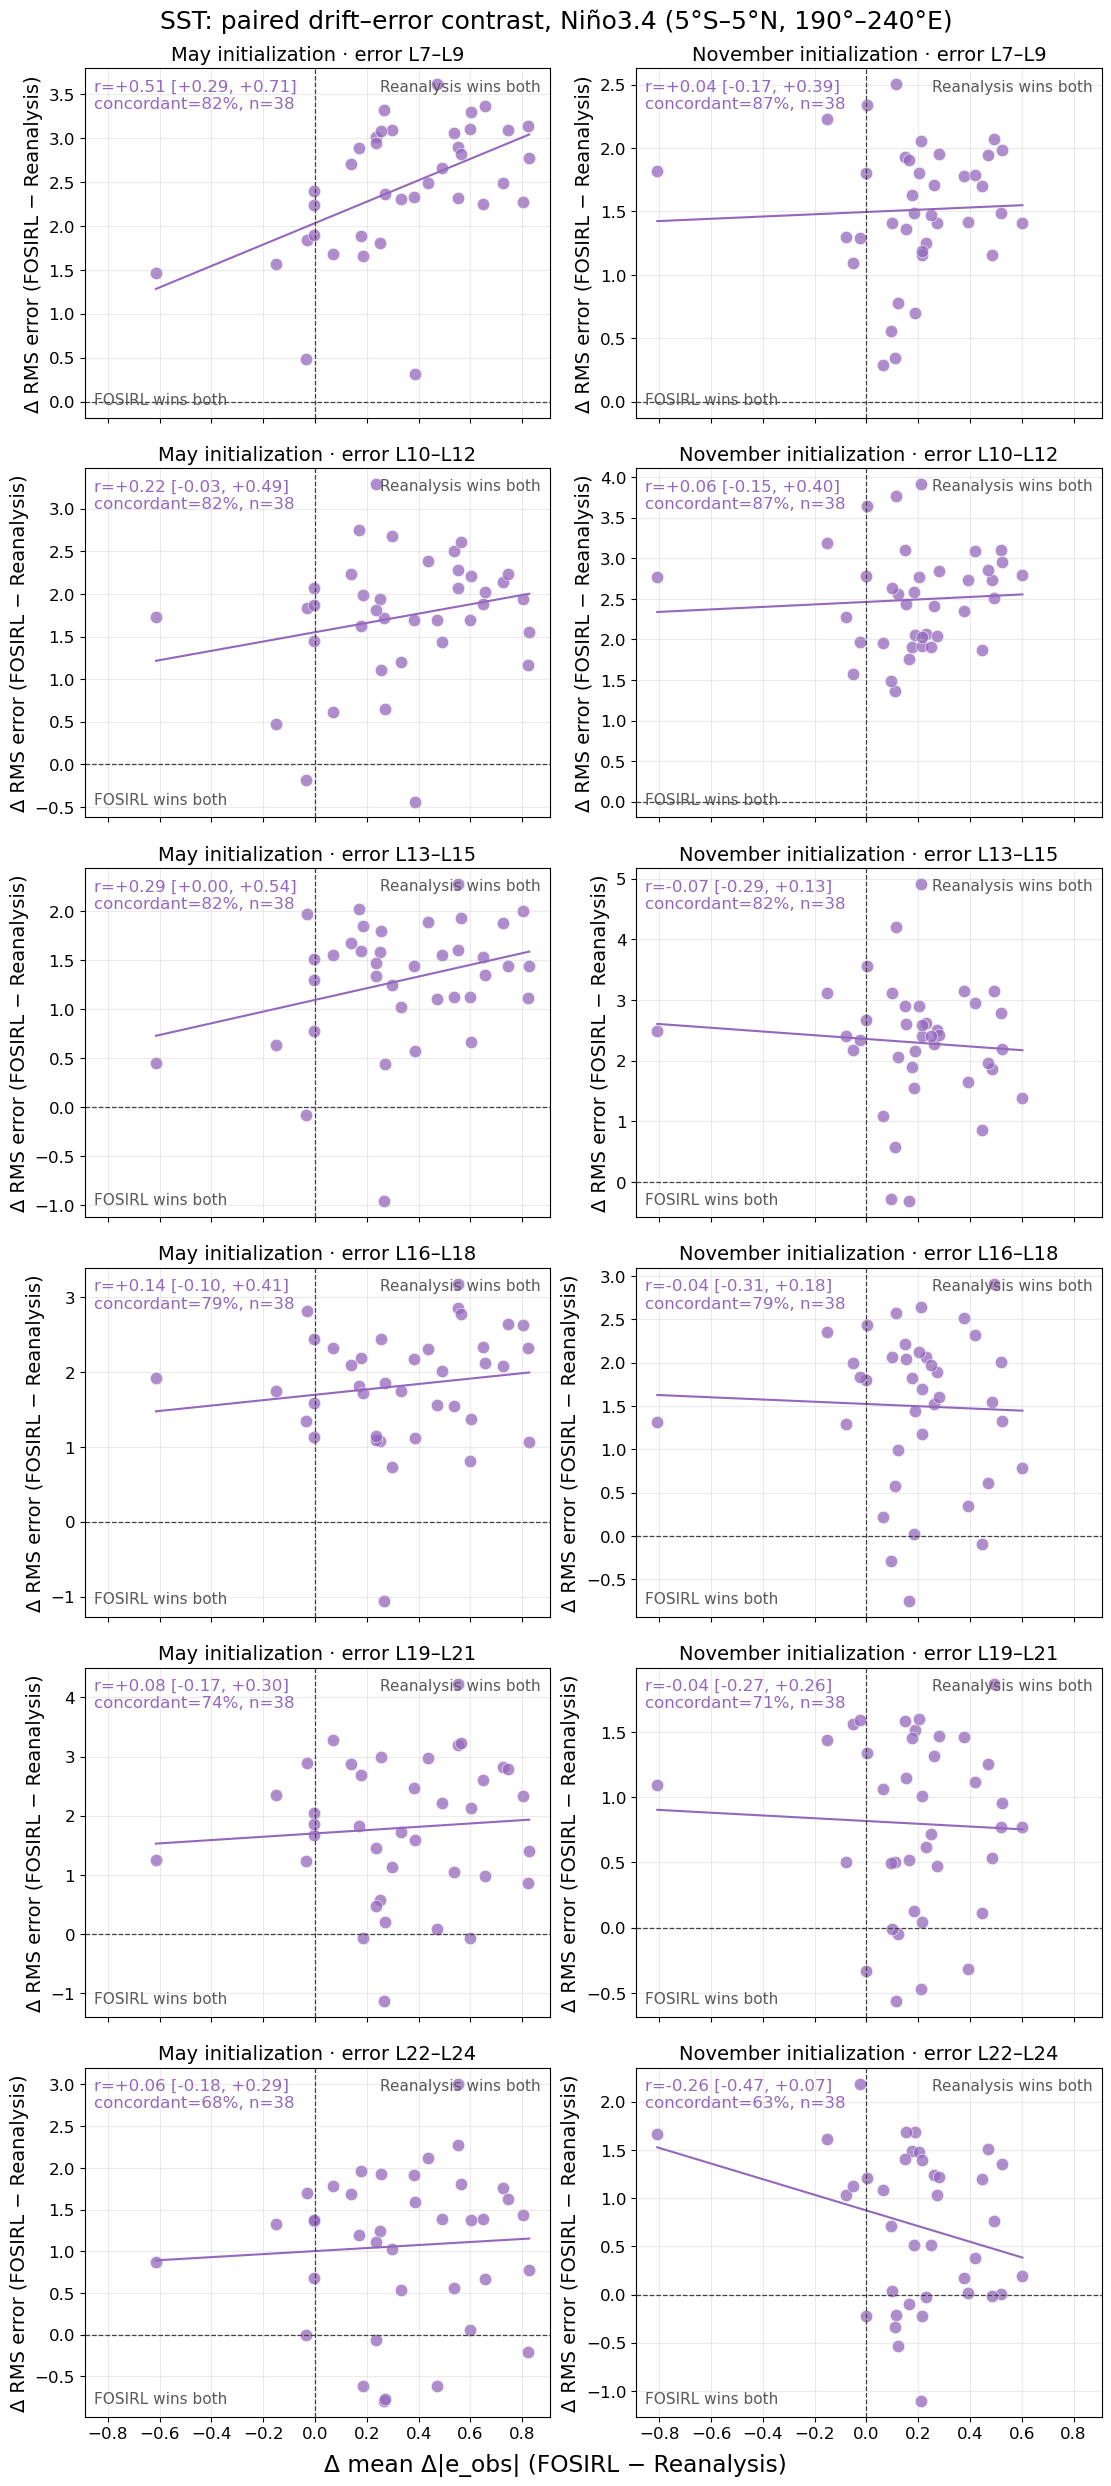

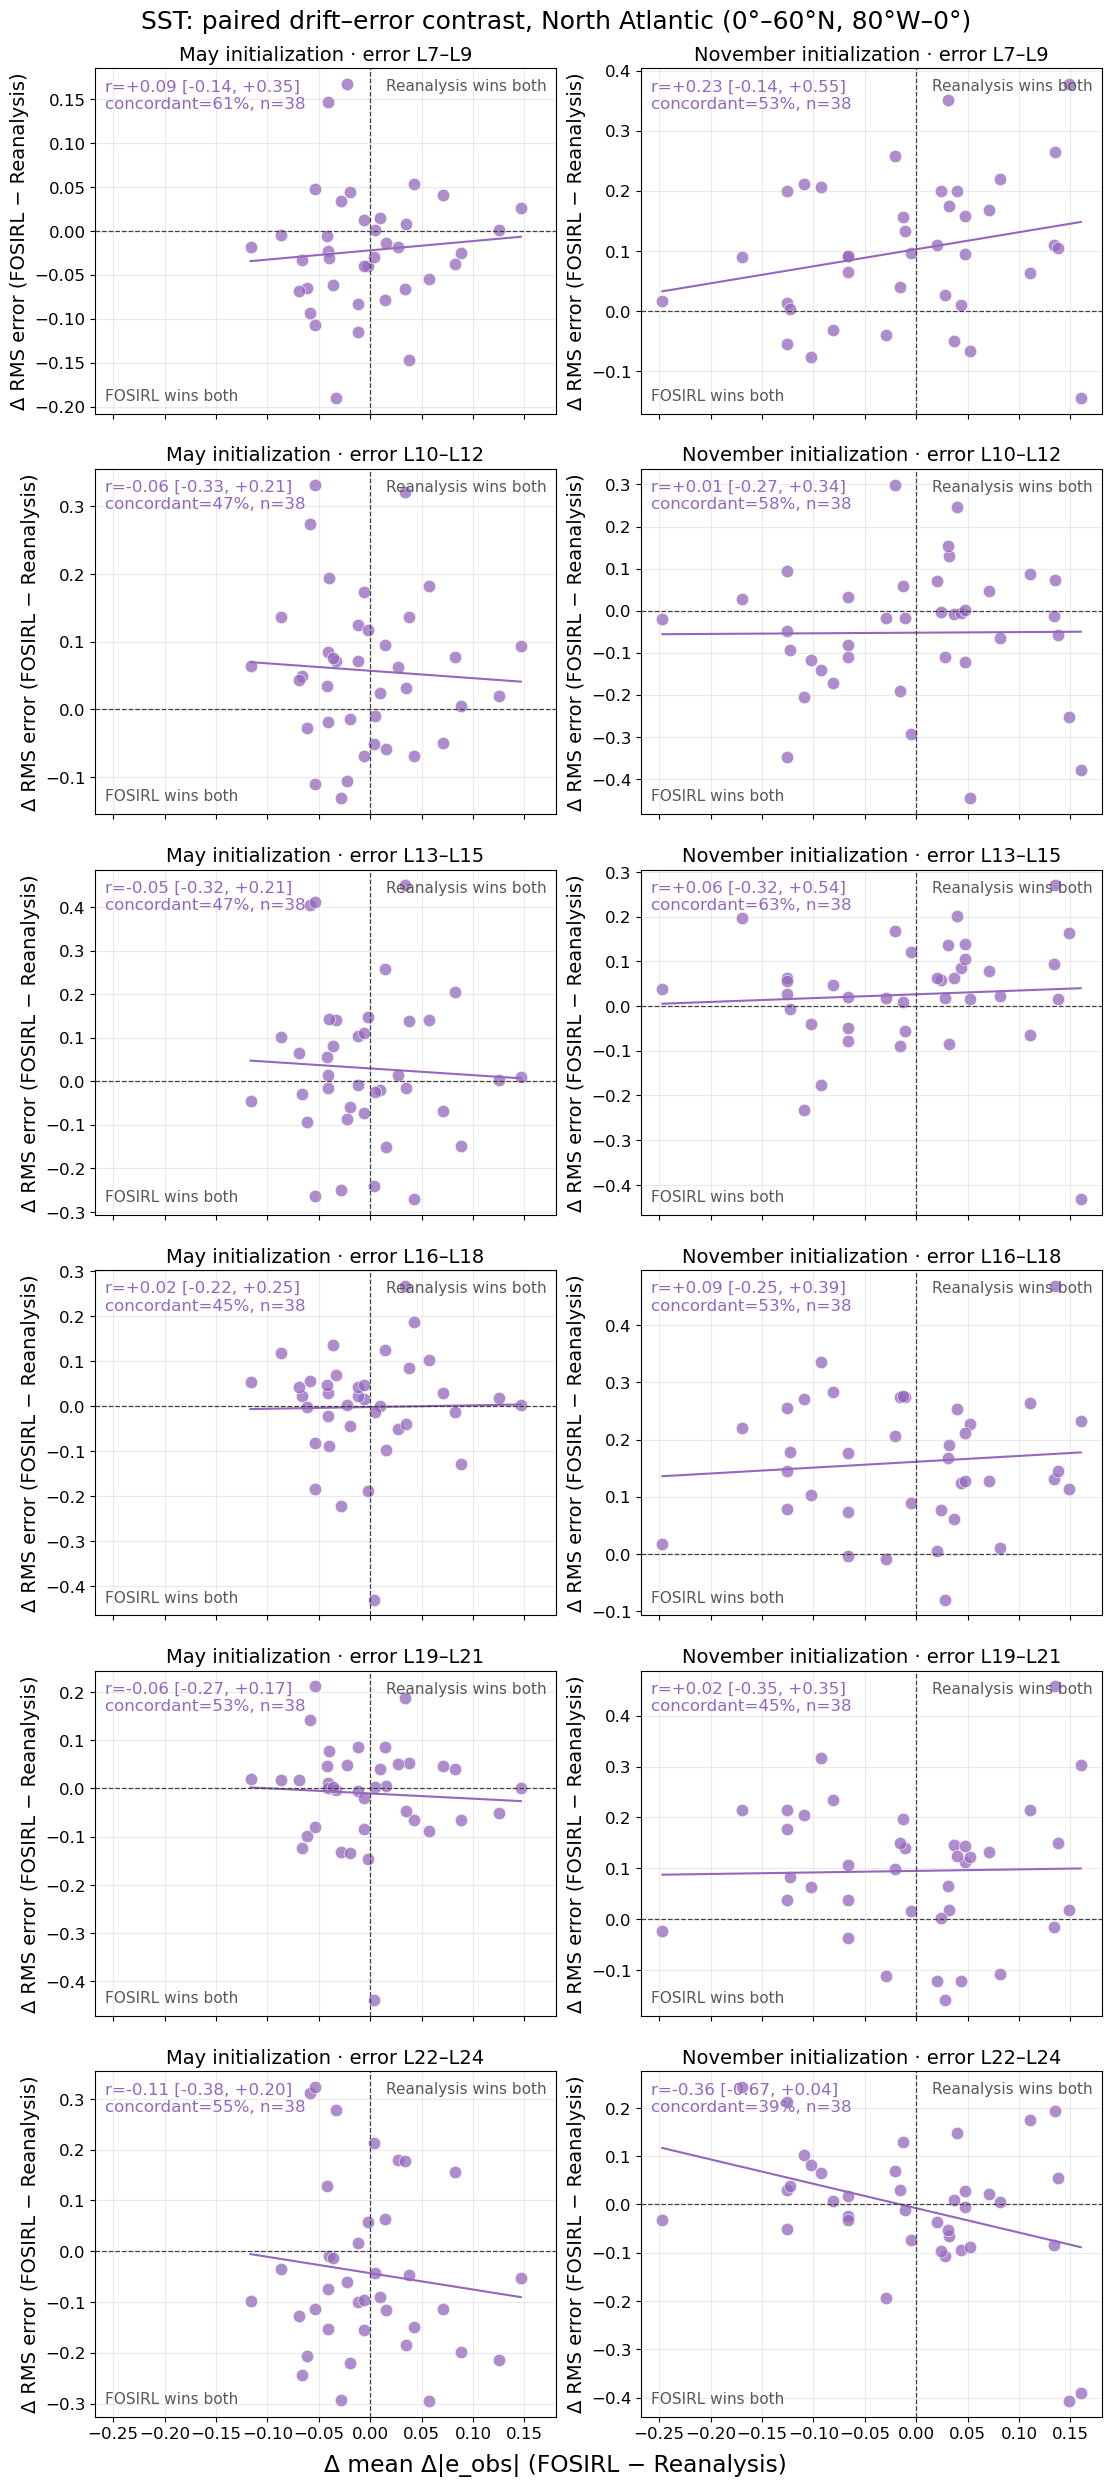

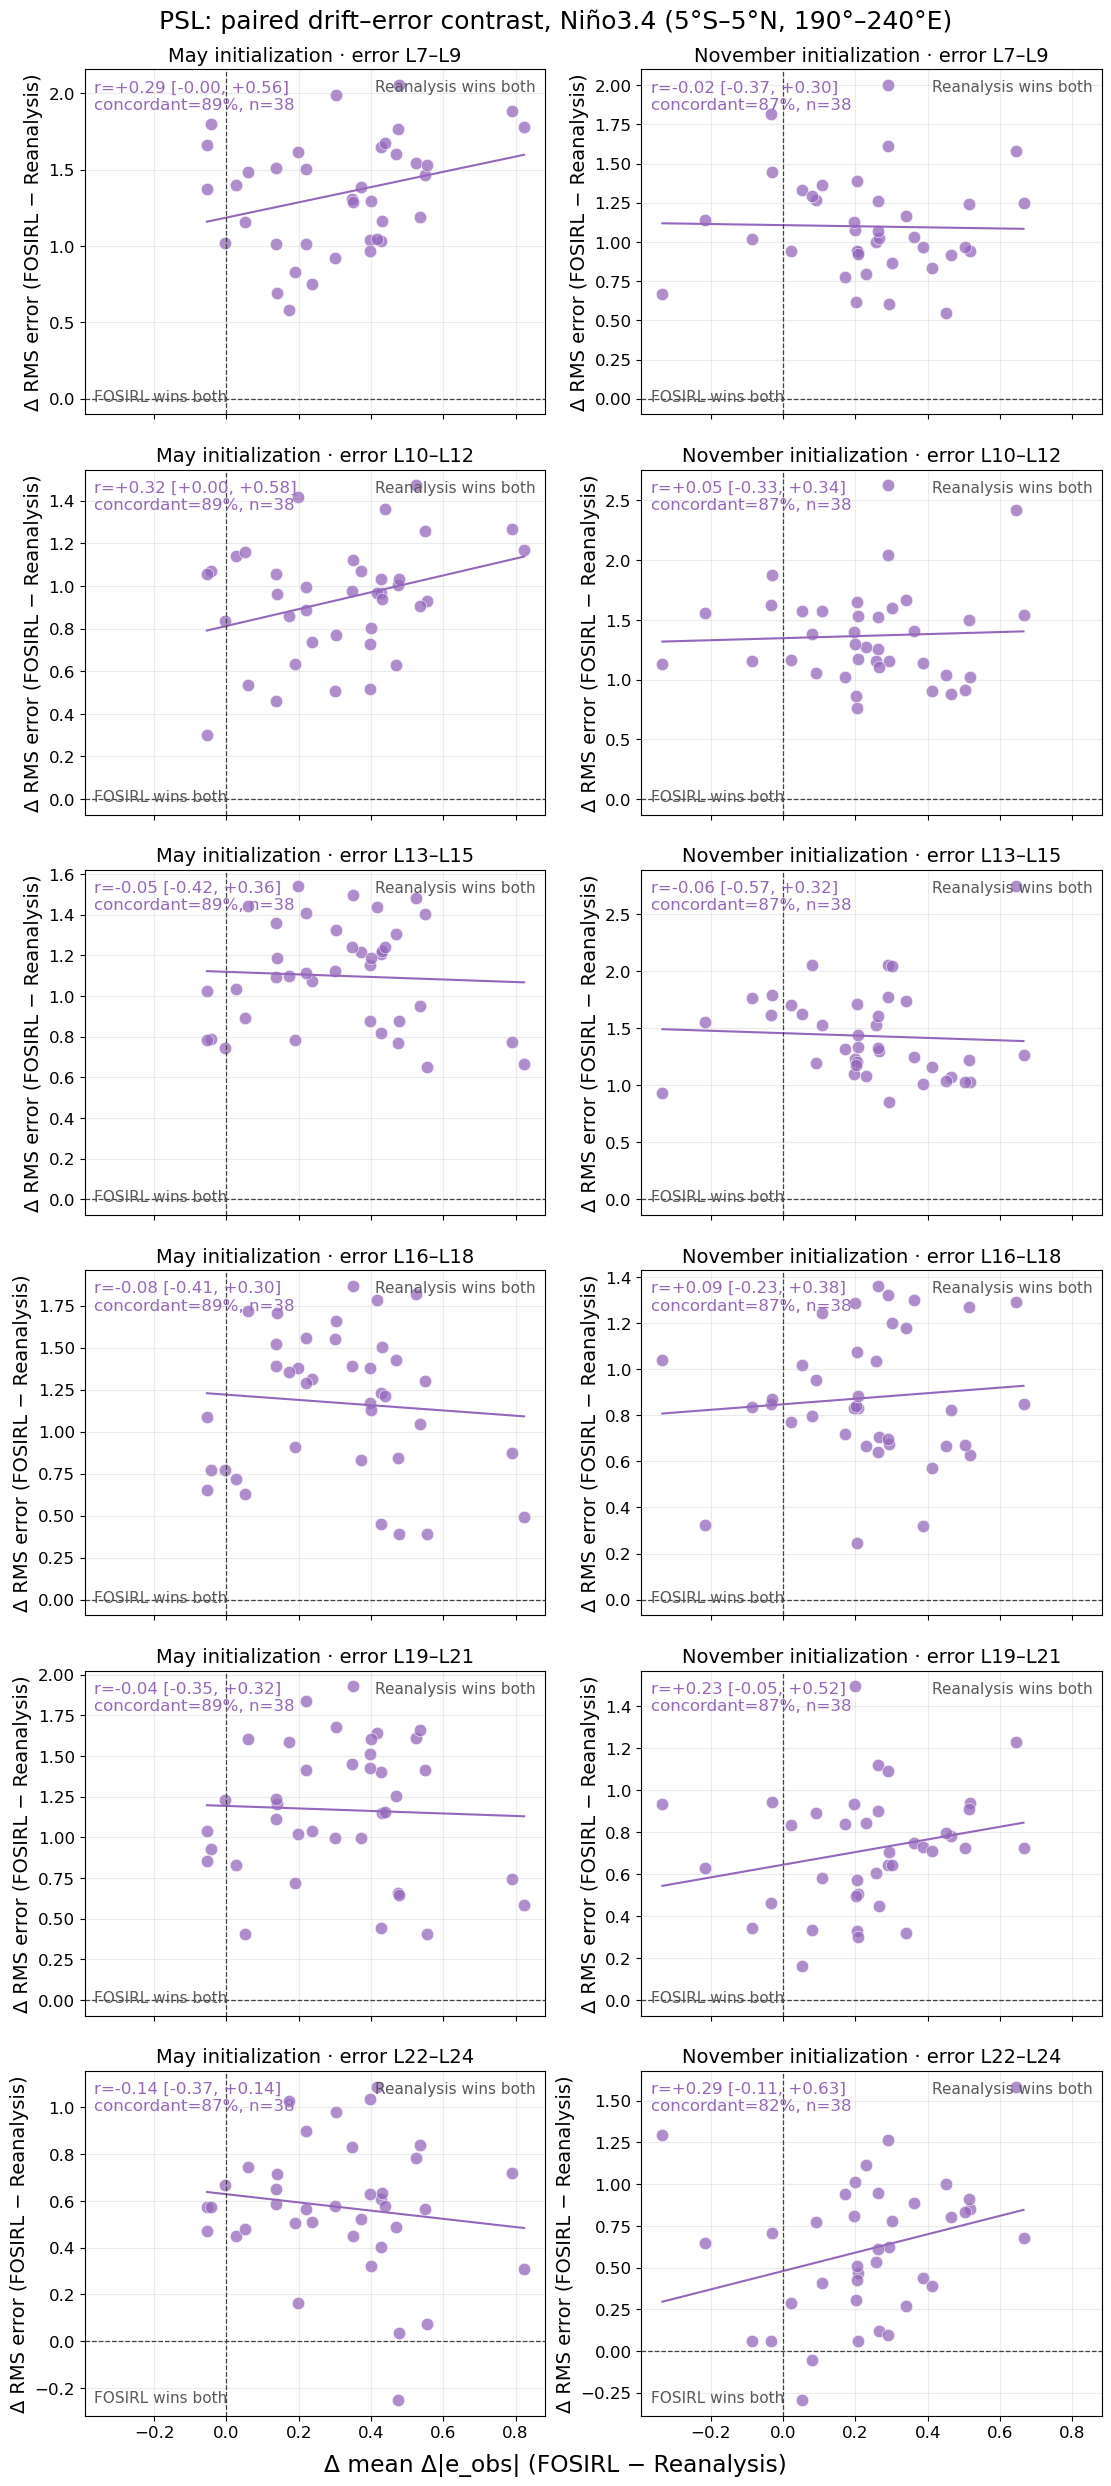

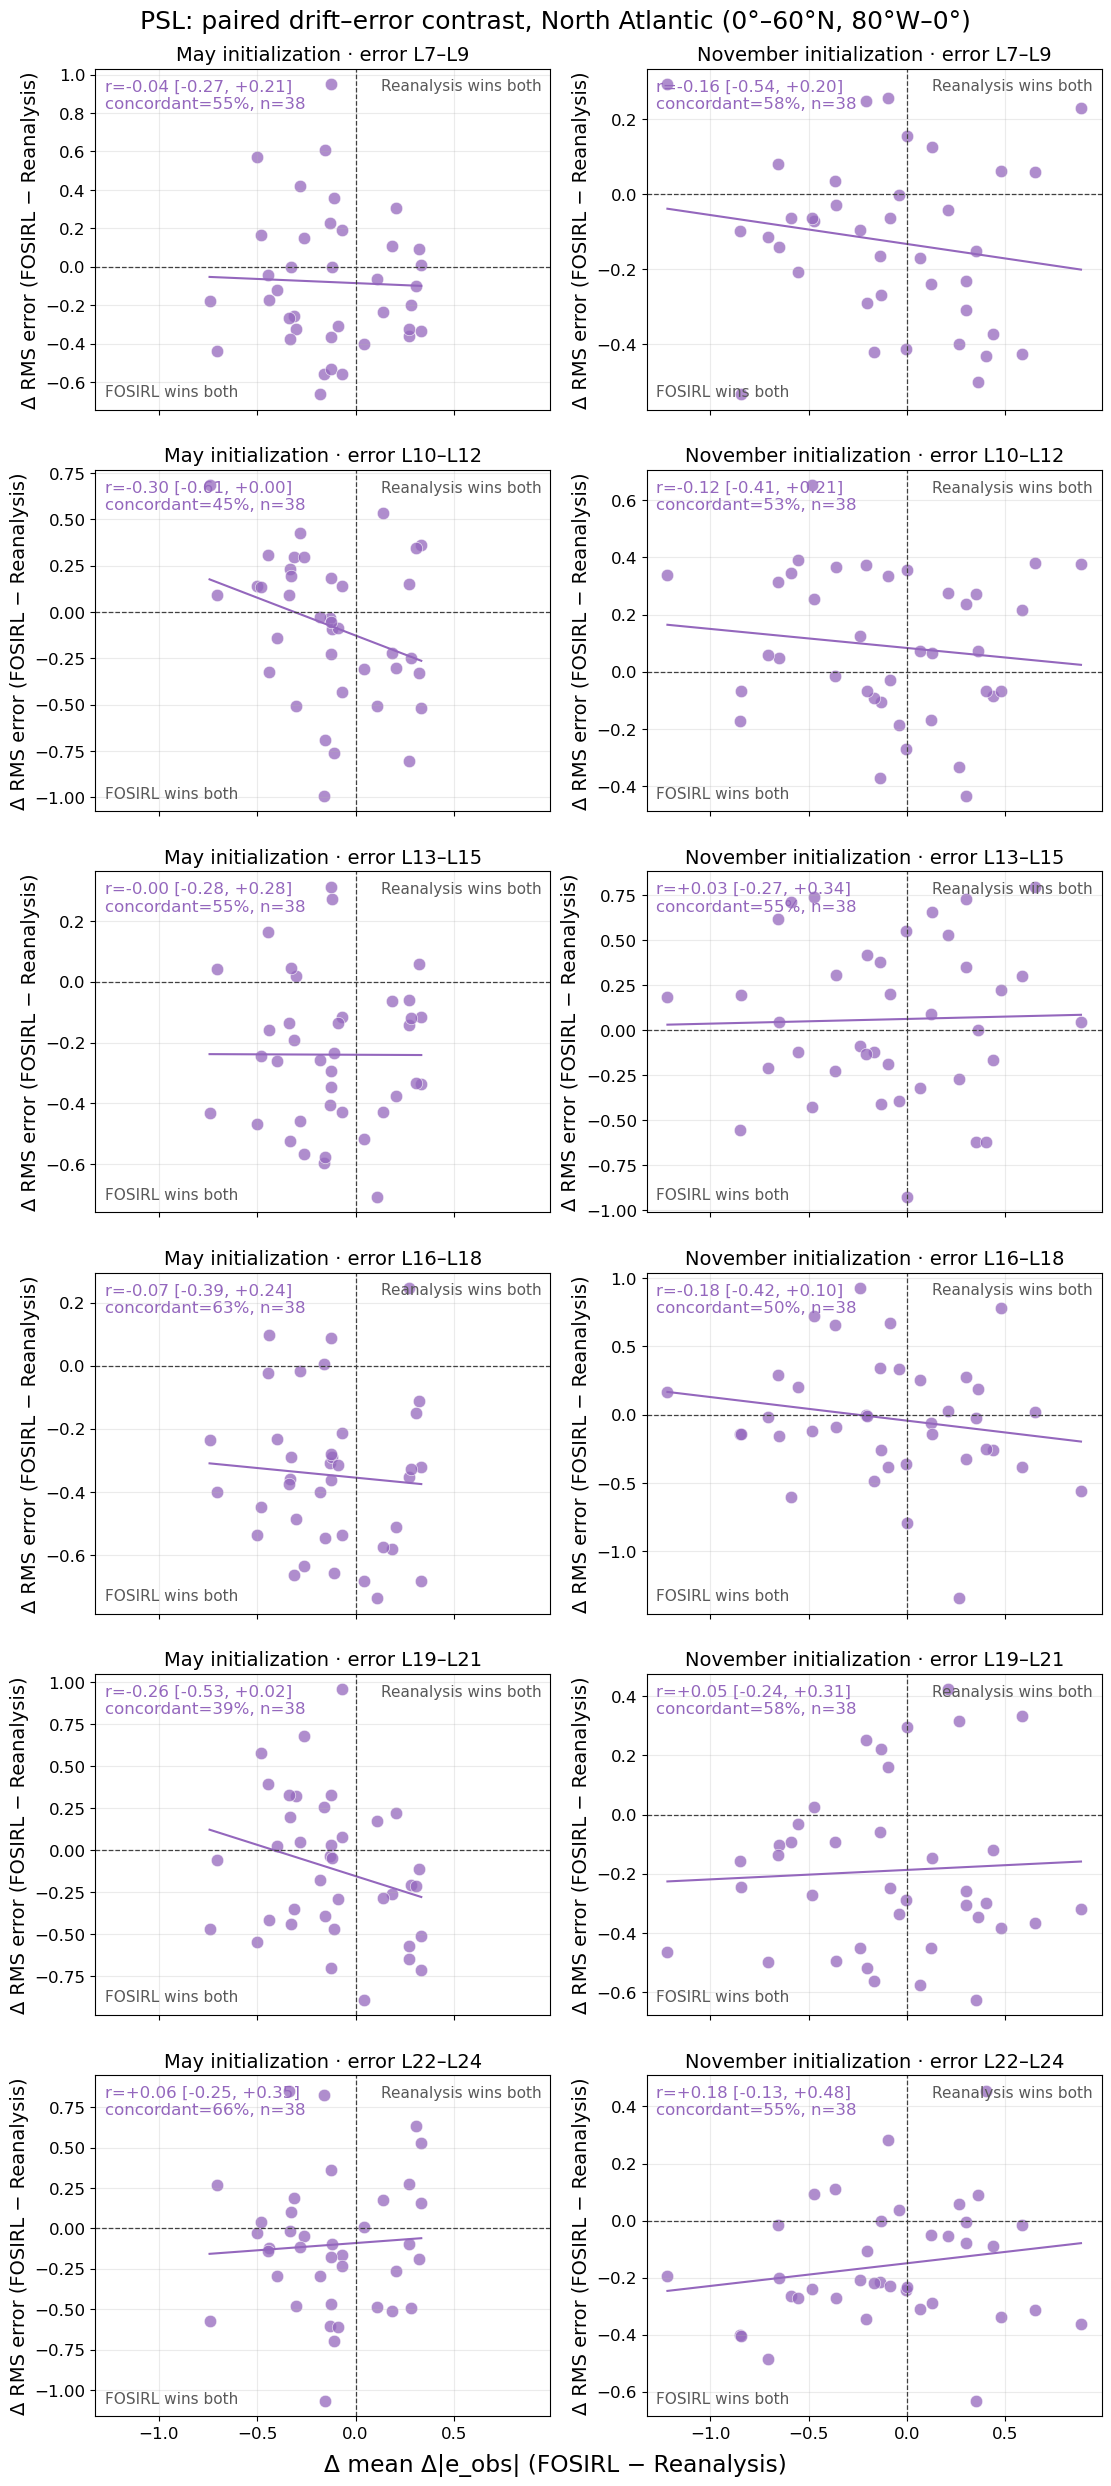

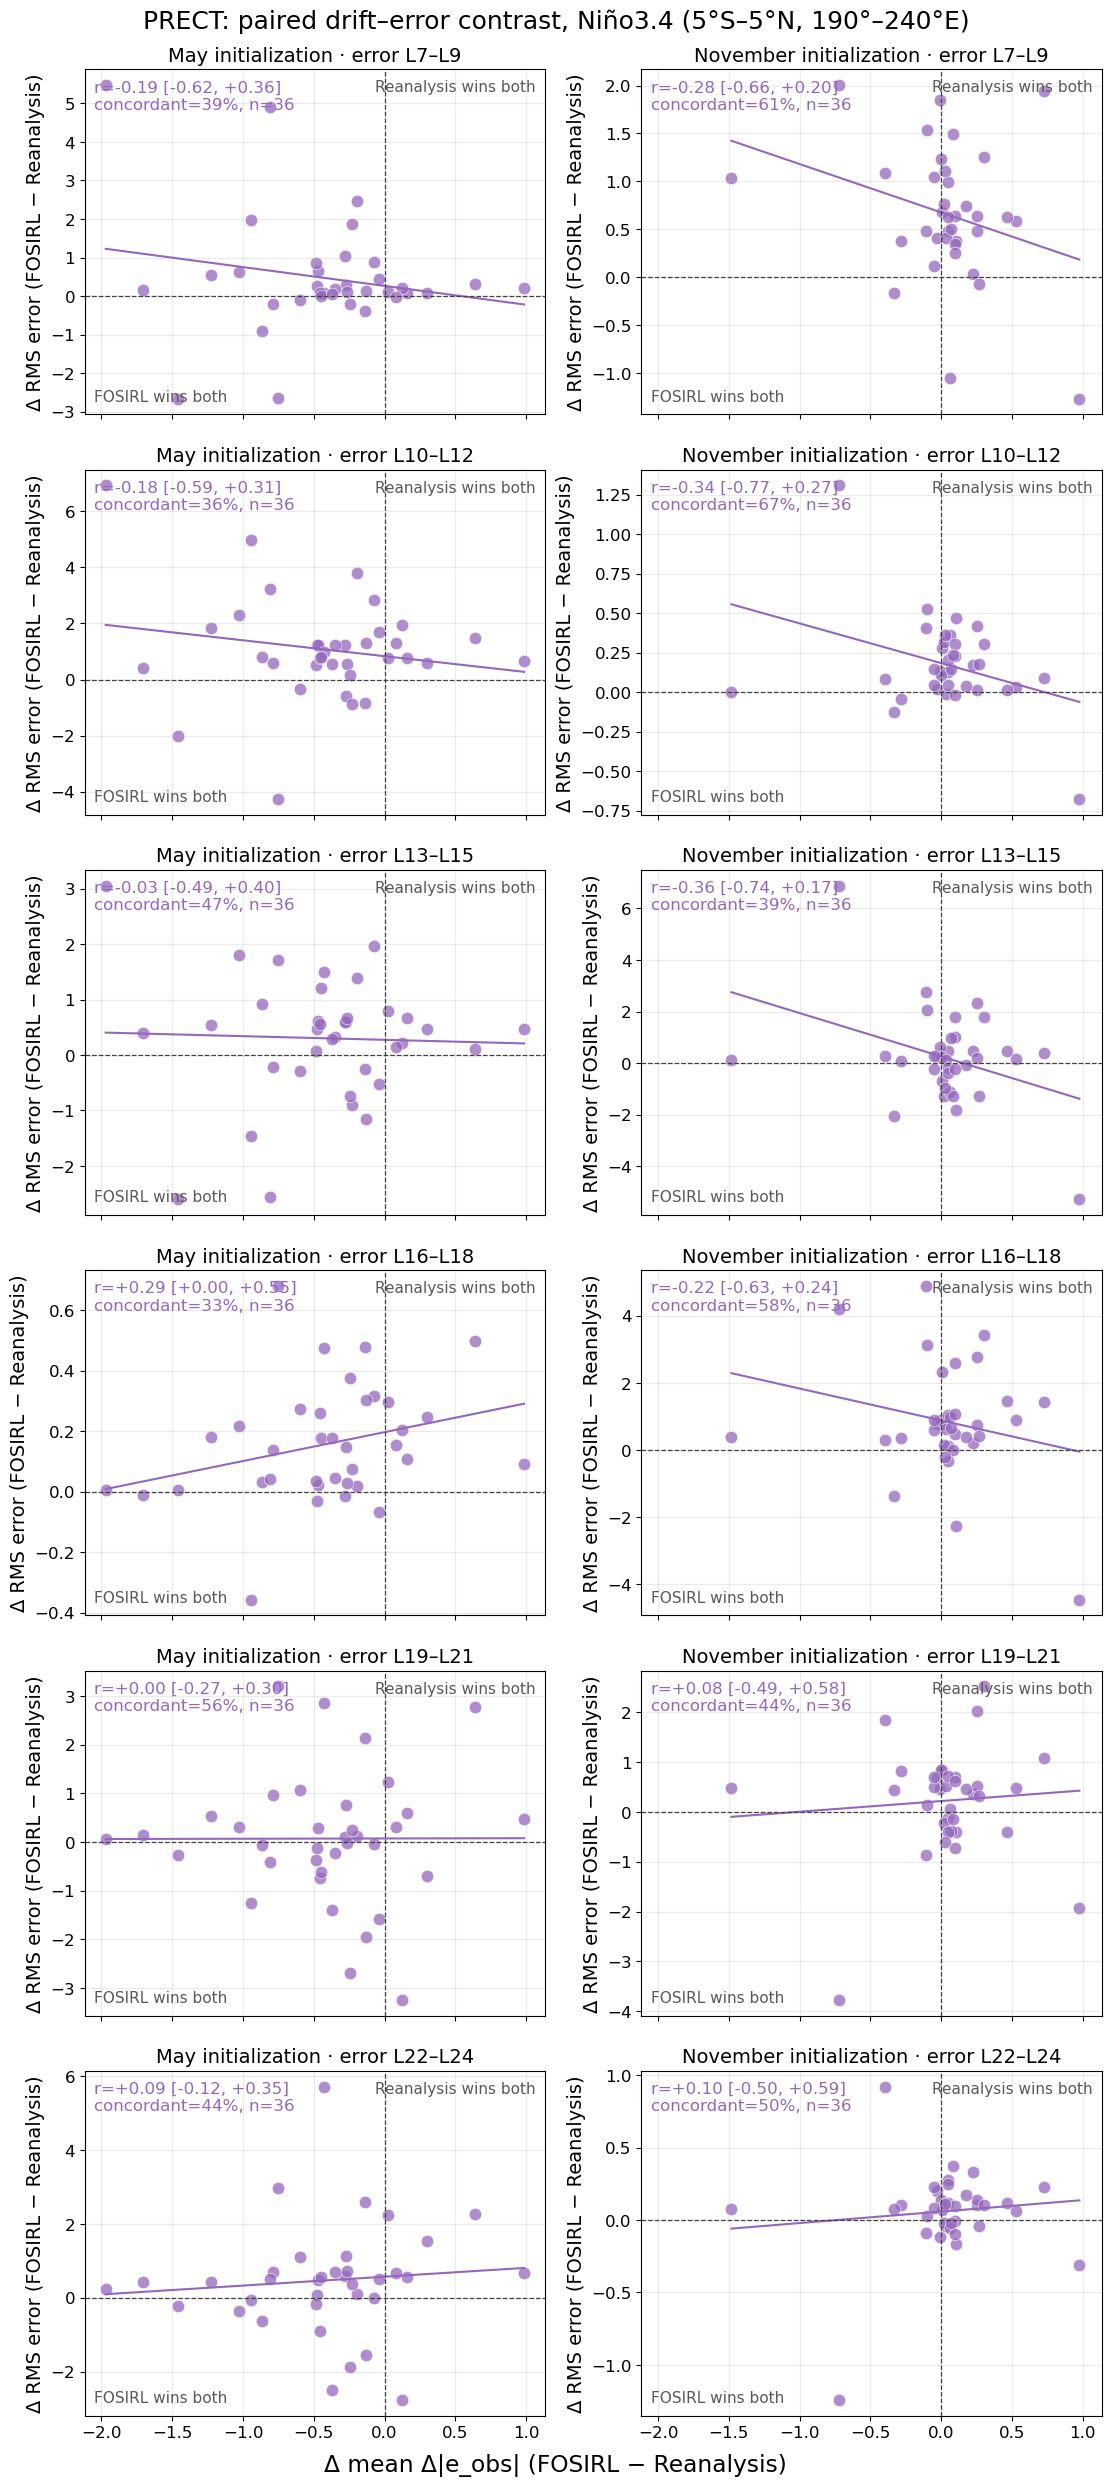

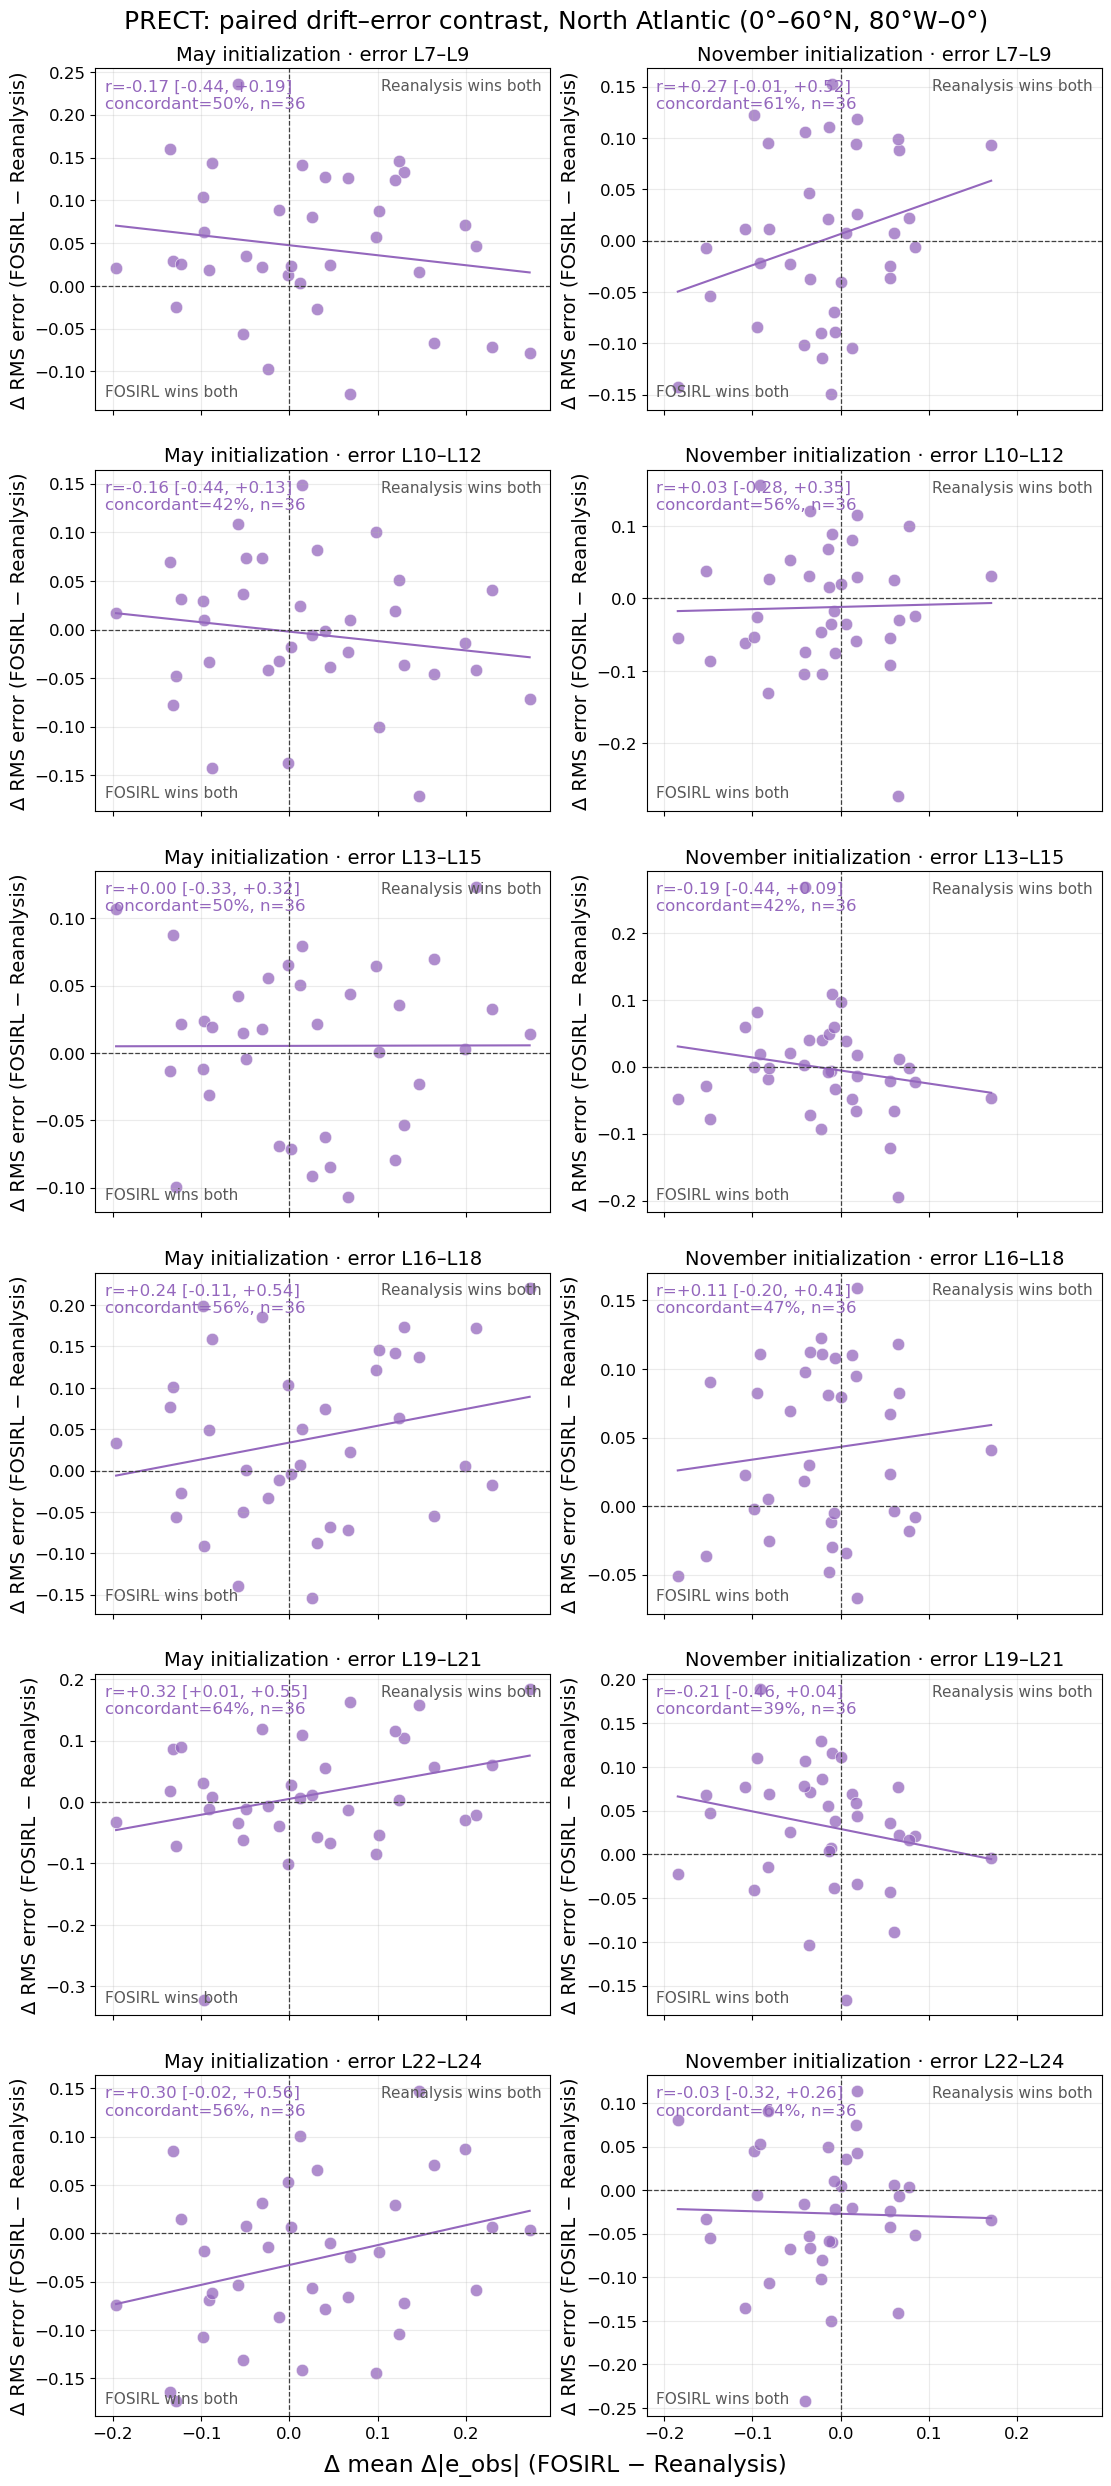

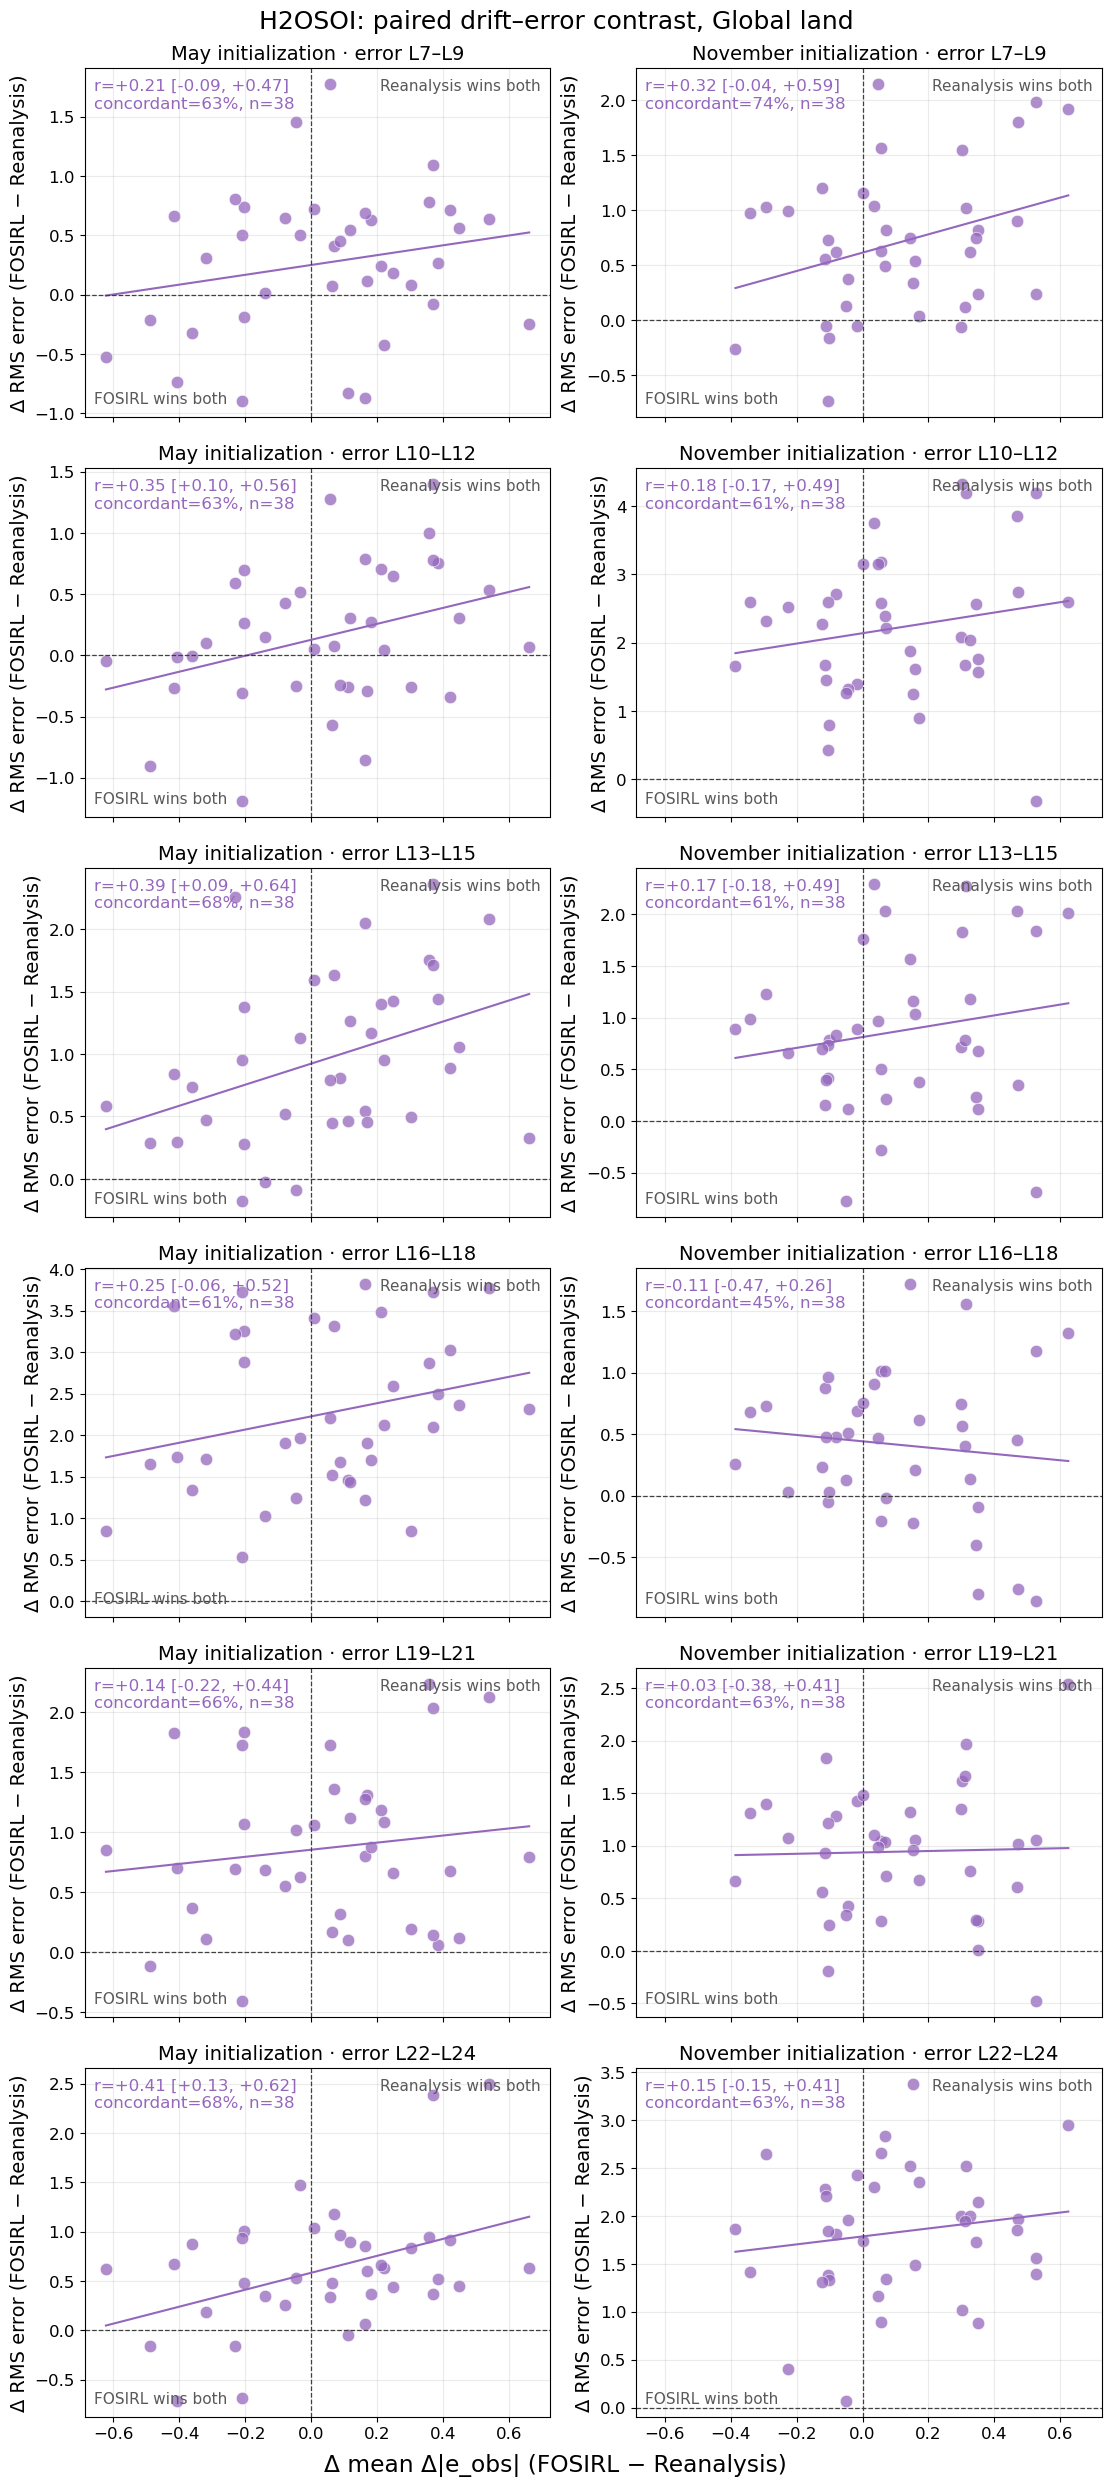

,variable,region,init_month,early_leads,late_leads,correlation,correlation_ci_lower,correlation_ci_upper,concordance_fraction,n_starts
0,TREFHT,Nino3.4,5,L1–L3,L7–L9,0.511,0.315,0.666,0.658,38
1,TREFHT,Nino3.4,11,L1–L3,L7–L9,0.052,-0.238,0.349,0.737,38
2,TREFHT,Nino3.4,5,L1–L3,L10–L12,-0.027,-0.290,0.263,0.632,38
3,TREFHT,Nino3.4,11,L1–L3,L10–L12,0.139,-0.164,0.493,0.763,38
4,TREFHT,Nino3.4,5,L1–L3,L13–L15,-0.023,-0.272,0.226,0.632,38
...,...,...,...,...,...,...,...,...,...,...
103,H2OSOI,Global_land,11,L1–L3,L16–L18,-0.108,-0.470,0.265,0.447,38
104,H2OSOI,Global_land,5,L1–L3,L19–L21,0.135,-0.223,0.444,0.658,38
105,H2OSOI,Global_land,11,L1–L3,L19–L21,0.027,-0.385,0.406,0.632,38
106,H2OSOI,Global_land,5,L1–L3,L22–L24,0.413,0.132,0.623,0.684,38


/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_paired_drift_error_correlations.csv


In [31]:
paired_figure_paths = []
paired_rows = []
for variable in VARIABLES:
    for region_name in PLOT_REGIONS[variable]:
        fig, axes = plt.subplots(
            len(LATE_ERROR_WINDOWS), len(INIT_MONTHS),
            figsize=figure_size(), sharex=True, squeeze=False,
            constrained_layout=True,
        )
        for row, late_leads in enumerate(LATE_ERROR_WINDOWS):
            for col, init_month in enumerate(INIT_MONTHS):
                ax = axes[row, col]
                relationships = {}
                for source in SOURCES:
                    fields = drift_skill_inputs[(
                        variable, init_month, source
                    )].sel(region=region_name)
                    relationships[source] = compute_early_drift_late_error(
                        fields.delta_abs_e_obs, fields.e_obs,
                        early_leads=EARLY_LEADS, late_leads=late_leads,
                    )

                paired = compare_drift_skill_relationship(
                    relationships['JRA55_FOSIRL'],
                    relationships['Reanalysis'],
                )
                interval = bootstrap_paired_correlation_ci(
                    paired.delta_drift, paired.delta_error,
                    n_bootstrap=N_BOOTSTRAP,
                    confidence=BOOTSTRAP_CONFIDENCE,
                    seed=BOOTSTRAP_SEED,
                )
                x = np.asarray(paired.delta_drift).reshape(-1)
                y = np.asarray(paired.delta_error).reshape(-1)
                finite = np.isfinite(x) & np.isfinite(y)
                x, y = x[finite], y[finite]
                correlation = float(paired.correlation)
                ci_lower = float(interval.ci_lower)
                ci_upper = float(interval.ci_upper)
                concordance = float(paired.concordance_fraction)

                ax.scatter(
                    x, y, s=PAIRED_SCATTER_SIZE, alpha=SCATTER_ALPHA,
                    color='tab:purple', edgecolor='white', linewidth=0.5,
                )
                if x.size >= 2 and not np.allclose(x, x[0]):
                    slope, intercept = np.polyfit(x, y, 1)
                    x_line = np.linspace(float(x.min()), float(x.max()), 100)
                    ax.plot(
                        x_line, slope * x_line + intercept,
                        color='tab:purple', linewidth=1.5,
                    )
                ax.axvline(0, color='0.25', linewidth=0.9, linestyle='--')
                ax.axhline(0, color='0.25', linewidth=0.9, linestyle='--')
                ax.text(
                    0.02, 0.97,
                    f'r={correlation:+.2f} '
                    f'[{ci_lower:+.2f}, {ci_upper:+.2f}]\n'
                    f'concordant={concordance:.0%}, n={x.size}',
                    transform=ax.transAxes, ha='left', va='top',
                    color='tab:purple', fontsize=ANNOTATION_FONT_SIZE,
                )
                ax.text(
                    0.02, 0.03, 'FOSIRL wins both',
                    transform=ax.transAxes, ha='left', va='bottom',
                    color='0.35', fontsize=ANNOTATION_FONT_SIZE - 1,
                )
                ax.text(
                    0.98, 0.97, 'Reanalysis wins both',
                    transform=ax.transAxes, ha='right', va='top',
                    color='0.35', fontsize=ANNOTATION_FONT_SIZE - 1,
                )
                ax.set_title(
                    f'{MONTH_NAMES[init_month]} initialization · '
                    f'error {lead_window_label(late_leads)}'
                )
                ax.set_ylabel('Δ RMS error (FOSIRL − Reanalysis)')
                ax.grid(True, alpha=0.25)
                ax.set_box_aspect(
                    PANEL_ASPECT_RATIO[1] / PANEL_ASPECT_RATIO[0]
                )

                paired_rows.append({
                    'variable': variable, 'region': region_name,
                    'init_month': init_month,
                    'early_leads': lead_window_label(EARLY_LEADS),
                    'late_leads': lead_window_label(late_leads),
                    'correlation': correlation,
                    'correlation_ci_lower': ci_lower,
                    'correlation_ci_upper': ci_upper,
                    'concordance_fraction': concordance,
                    'n_starts': x.size,
                })

        fig.suptitle(
            f'{variable}: paired drift–error contrast, '
            f'{REGION_LABELS[region_name]}'
        )
        fig.supxlabel(
            'Δ mean Δ|e_obs| (FOSIRL − Reanalysis)'
        )
        path = FIGURE_ROOT / (
            f'{FIGURE_PREFIX}_{variable}_May_Nov_'
            f'{REGION_FILE_LABELS[region_name]}_paired_drift_error.png'
        )
        fig.savefig(path, dpi=FIGURE_DPI, bbox_inches='tight')
        if SHOW_FIGURES_INLINE:
            display(fig)
        plt.close(fig)
        paired_figure_paths.append(path)

paired_table = pd.DataFrame(paired_rows)
paired_table_path = FIGURE_ROOT / (
    f'{FIGURE_PREFIX}_paired_drift_error_correlations.csv'
)
paired_table.to_csv(paired_table_path, index=False)
display(paired_table.round({
    'correlation': 3, 'correlation_ci_lower': 3,
    'correlation_ci_upper': 3, 'concordance_fraction': 3,
}))
print(paired_table_path)

### Output validation

In [32]:
expected_figure_count = sum(
    len(PLOT_REGIONS[variable]) for variable in VARIABLES
)
expected_rows = (
    expected_figure_count * len(INIT_MONTHS)
    * len(LATE_ERROR_WINDOWS) * len(SOURCES)
)
assert len(figure_paths) == expected_figure_count
assert all(path.is_file() and path.stat().st_size > 0 for path in figure_paths)
assert len(correlation_table) == expected_rows
assert correlation_path.is_file() and correlation_path.stat().st_size > 0
assert correlation_table['n_starts'].ge(2).all()
assert correlation_table['correlation'].dropna().between(-1, 1).all()
assert len(paired_figure_paths) == expected_figure_count
assert all(
    path.is_file() and path.stat().st_size > 0
    for path in paired_figure_paths
)
paired_expected_rows = (
    expected_figure_count * len(INIT_MONTHS) * len(LATE_ERROR_WINDOWS)
)
assert len(paired_table) == paired_expected_rows
assert paired_table_path.is_file() and paired_table_path.stat().st_size > 0
assert paired_table['n_starts'].ge(3).all()
assert paired_table['correlation'].dropna().between(-1, 1).all()
assert paired_table['correlation_ci_lower'].dropna().between(-1, 1).all()
assert paired_table['correlation_ci_upper'].dropna().between(-1, 1).all()
assert paired_table['concordance_fraction'].dropna().between(0, 1).all()
print(
    f'Validated {len(figure_paths)} within-strategy and '
    f'{len(paired_figure_paths)} paired drift–error figures; '
    f'{len(correlation_table)} within-strategy and '
    f'{len(paired_table)} paired correlation records.'
)

Validated 9 within-strategy and 9 paired drift–error figures; 216 within-strategy and 108 paired correlation records.
